In [1]:
# ============================================================
# Phase 2 | Cell 1: Imports + Data Load
# 02_structural_anchor.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.stattools import coint

PROCESSED = '../data/processed/'
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# ── Load clean modeling dataset ───────────────────────────────
model = pd.read_csv(f'{PROCESSED}master_model.csv',
                    index_col=0, parse_dates=True)
model.index = pd.to_datetime(model.index).to_period('M').to_timestamp()

print("✓ master_model.csv loaded")
print(f"  Shape      : {model.shape}")
print(f"  Date range : {model.index[0].strftime('%b %Y')} → "
      f"{model.index[-1].strftime('%b %Y')}")
print(f"  Nulls      : {model.isnull().sum().sum()}")
print()
print("Phase 2 objective:")
print("  Separate justified INR depreciation from genuine misalignment")
print("  Method: Balassa-Samuelson decomposition + Johansen cointegration + VECM")

✓ master_model.csv loaded
  Shape      : (255, 42)
  Date range : Apr 2004 → Jun 2025
  Nulls      : 0

Phase 2 objective:
  Separate justified INR depreciation from genuine misalignment
  Method: Balassa-Samuelson decomposition + Johansen cointegration + VECM


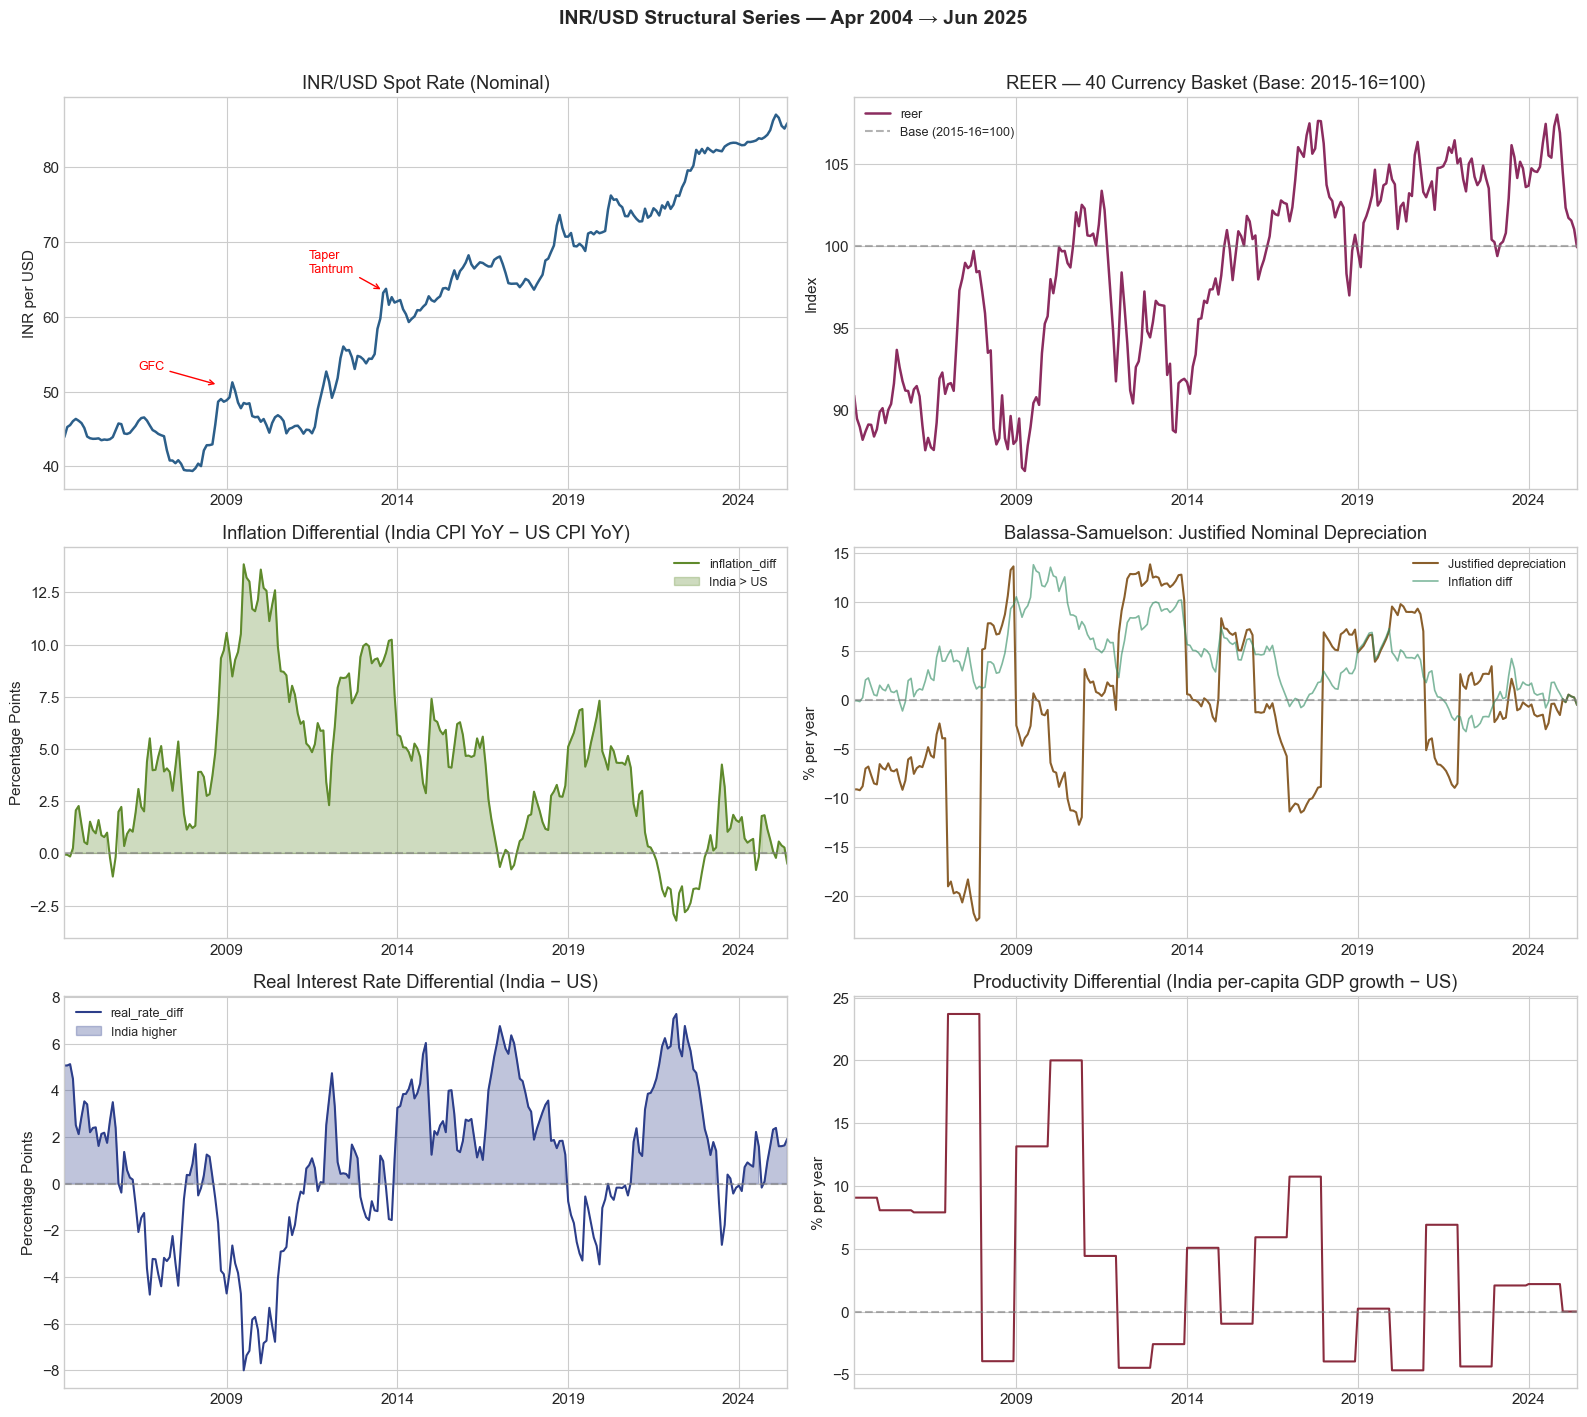

✓ Chart saved → outputs/02_structural_series.png


In [2]:
# ============================================================
# Phase 2 | Cell 2: Visual Exploration of Structural Series
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('INR/USD Structural Series — Apr 2004 → Jun 2025',
             fontsize=14, fontweight='bold', y=1.01)

# 1. INR/USD nominal
ax = axes[0, 0]
model['inr_usd'].plot(ax=ax, color='#2c5f8a', linewidth=1.8)
ax.set_title('INR/USD Spot Rate (Nominal)')
ax.set_ylabel('INR per USD')
ax.annotate('GFC', xy=(pd.Timestamp('2008-10-01'), 50.9),
            xytext=(pd.Timestamp('2006-06-01'), 53),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.annotate('Taper\nTantrum', xy=(pd.Timestamp('2013-08-01'), 63.5),
            xytext=(pd.Timestamp('2011-06-01'), 66),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# 2. REER (real effective exchange rate)
ax = axes[0, 1]
model['reer'].plot(ax=ax, color='#8b2c5f', linewidth=1.8)
ax.axhline(100, color='gray', linestyle='--', alpha=0.6, label='Base (2015-16=100)')
ax.set_title('REER — 40 Currency Basket (Base: 2015-16=100)')
ax.set_ylabel('Index')
ax.legend(fontsize=9)

# 3. Inflation differential (India - US)
ax = axes[1, 0]
model['inflation_diff'].dropna().plot(ax=ax, color='#5f8a2c', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
ax.fill_between(model['inflation_diff'].dropna().index,
                model['inflation_diff'].dropna(), 0,
                where=model['inflation_diff'].dropna() > 0,
                alpha=0.3, color='#5f8a2c', label='India > US')
ax.set_title('Inflation Differential (India CPI YoY − US CPI YoY)')
ax.set_ylabel('Percentage Points')
ax.legend(fontsize=9)

# 4. Justified depreciation trend
ax = axes[1, 1]
model['justified_depreciation'].dropna().plot(
    ax=ax, color='#8a5f2c', linewidth=1.5, label='Justified depreciation')
model['inflation_diff'].dropna().plot(
    ax=ax, color='#2c8a5f', linewidth=1.2, alpha=0.6, label='Inflation diff')
ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
ax.set_title('Balassa-Samuelson: Justified Nominal Depreciation')
ax.set_ylabel('% per year')
ax.legend(fontsize=9)

# 5. Real interest rate differential
ax = axes[2, 0]
model['real_rate_diff'].dropna().plot(ax=ax, color='#2c3e8a', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
ax.fill_between(model['real_rate_diff'].dropna().index,
                model['real_rate_diff'].dropna(), 0,
                where=model['real_rate_diff'].dropna() > 0,
                alpha=0.3, color='#2c3e8a', label='India higher')
ax.set_title('Real Interest Rate Differential (India − US)')
ax.set_ylabel('Percentage Points')
ax.legend(fontsize=9)

# 6. Productivity differential
ax = axes[2, 1]
model['prod_diff'].dropna().plot(ax=ax, color='#8a2c3e', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
ax.set_title('Productivity Differential (India per-capita GDP growth − US)')
ax.set_ylabel('% per year')

plt.tight_layout()
plt.savefig('../outputs/02_structural_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved → outputs/02_structural_series.png")

In [3]:
# ============================================================
# Phase 2 | Cell 3: Stationarity Tests (ADF + KPSS)
# ============================================================

# Series to test — our structural anchor variables
# These are the candidates for the cointegrating relationship
test_series = {
    'inr_usd'               : 'INR/USD Spot',
    'reer'                  : 'REER (40-currency)',
    'cpi_india'             : 'CPI India (level)',
    'cpi_us'                : 'CPI US (level)',
    'inflation_diff'        : 'Inflation Differential',
    'prod_diff'             : 'Productivity Differential',
    'justified_depreciation': 'Justified Depreciation',
    'real_rate_diff'        : 'Real Rate Differential',
}

def adf_test(series, name, maxlag=12):
    """ADF test — H0: unit root (non-stationary). Reject H0 → stationary."""
    s = series.dropna()
    result = adfuller(s, maxlag=maxlag, autolag='AIC', regression='c')
    return {
        'name'    : name,
        'adf_stat': round(result[0], 4),
        'p_value' : round(result[1], 4),
        'lags'    : result[2],
        'n_obs'   : result[3],
        'crit_1%' : round(result[4]['1%'], 3),
        'crit_5%' : round(result[4]['5%'], 3),
        'stationary_5pct': result[1] < 0.05,
    }

def kpss_test(series, name):
    """KPSS test — H0: stationary. Reject H0 → non-stationary (unit root)."""
    s = series.dropna()
    try:
        result = kpss(s, regression='c', nlags='auto')
        return {
            'kpss_stat'  : round(result[0], 4),
            'p_value'    : round(result[1], 4),
            'crit_5%'    : round(result[3]['5%'], 3),
            'stationary_5pct': result[1] > 0.05,
        }
    except:
        return {'kpss_stat': None, 'p_value': None,
                'crit_5%': None, 'stationary_5pct': None}

print("STATIONARITY TESTS — LEVELS")
print("=" * 70)
print(f"  {'Series':<28} {'ADF stat':>10} {'p-val':>7} "
      f"{'KPSS stat':>10} {'p-val':>7}  {'Verdict':>12}")
print("  " + "─" * 68)

results_levels = {}
for col, label in test_series.items():
    s = model[col].dropna()
    adf = adf_test(s, label)
    kps = kpss_test(s, label)

    # I(1) if: ADF fails to reject (p>0.05) AND KPSS rejects (p<0.05)
    adf_nonstat = not adf['stationary_5pct']   # True = non-stationary
    kpss_nonstat = not kps['stationary_5pct']  # True = non-stationary

    if adf_nonstat and kpss_nonstat:
        verdict = 'I(1) ✓'
    elif not adf_nonstat and not kpss_nonstat:
        verdict = 'I(0) —'
    else:
        verdict = 'Mixed ?'

    results_levels[col] = {'adf': adf, 'kpss': kps, 'verdict': verdict}

    kpss_stat = kps['kpss_stat'] if kps['kpss_stat'] else float('nan')
    kpss_p    = kps['p_value']   if kps['p_value']   else float('nan')

    print(f"  {label:<28} {adf['adf_stat']:>10.4f} {adf['p_value']:>7.4f} "
          f"{kpss_stat:>10.4f} {kpss_p:>7.4f}  {verdict:>12}")

print()
print("STATIONARITY TESTS — FIRST DIFFERENCES")
print("=" * 70)
print(f"  {'Series':<28} {'ADF stat':>10} {'p-val':>7} "
      f"{'KPSS stat':>10} {'p-val':>7}  {'Verdict':>12}")
print("  " + "─" * 68)

for col, label in test_series.items():
    s_diff = model[col].dropna().diff().dropna()
    adf  = adf_test(s_diff, label)
    kps  = kpss_test(s_diff, label)

    adf_stat  = not adf['stationary_5pct']
    kpss_stat = not kps['stationary_5pct']

    if not adf_stat and not kpss_stat:
        verdict = 'I(0) ✓'
    else:
        verdict = 'Still NS?'

    kpss_s = kps['kpss_stat'] if kps['kpss_stat'] else float('nan')
    kpss_p = kps['p_value']   if kps['p_value']   else float('nan')

    print(f"  {label:<28} {adf['adf_stat']:>10.4f} {adf['p_value']:>7.4f} "
          f"{kpss_s:>10.4f} {kpss_p:>7.4f}  {verdict:>12}")

print()
print("─" * 70)
print("INTERPRETATION GUIDE")
print("─" * 70)
print("""
  I(1) in levels + I(0) in differences = Unit root process
  This is REQUIRED for Johansen cointegration to be valid.

  ADF:  H0 = unit root.  p > 0.05 → fail to reject → non-stationary
  KPSS: H0 = stationary. p < 0.05 → reject → non-stationary

  Ideal result: series are I(1) in levels, I(0) in differences
  Cointegration then asks: do I(1) series share a common trend?
""")

STATIONARITY TESTS — LEVELS
  Series                         ADF stat   p-val  KPSS stat   p-val       Verdict
  ────────────────────────────────────────────────────────────────────
  INR/USD Spot                     0.0709  0.9640     2.3385  0.0100        I(1) ✓
  REER (40-currency)              -2.2755  0.1800     1.8281  0.0100        I(1) ✓
  CPI India (level)                0.6684  0.9892     2.4056  0.0100        I(1) ✓
  CPI US (level)                   1.8881  0.9985     2.2190  0.0100        I(1) ✓
  Inflation Differential          -1.9595  0.3046     0.6651  0.0167        I(1) ✓
  Productivity Differential       -2.4133  0.1380     0.8530  0.0100        I(1) ✓
  Justified Depreciation          -2.6292  0.0871     0.4402  0.0598       Mixed ?
  Real Rate Differential          -2.6477  0.0835     0.5030  0.0410        I(1) ✓

STATIONARITY TESTS — FIRST DIFFERENCES
  Series                         ADF stat   p-val  KPSS stat   p-val       Verdict
  ─────────────────────────────

C:\Users\imman\AppData\Local\Temp\ipykernel_7560\1871008119.py:37: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(s, regression='c', nlags='auto')
C:\Users\imman\AppData\Local\Temp\ipykernel_7560\1871008119.py:37: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(s, regression='c', nlags='auto')
C:\Users\imman\AppData\Local\Temp\ipykernel_7560\1871008119.py:37: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(s, regression='c', nlags='auto')
C:\Users\imman\AppData\Local\Temp\ipykernel_7560\1871008119.py:37: InterpolationWarning: The test statistic is outside of the range of p-values availab

In [4]:
# ============================================================
# Phase 2 | Cell 4: Johansen Cointegration Test
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import warnings
warnings.filterwarnings('ignore')

# ── Two cointegration systems to test ────────────────────────
#
# System 1 — PPP / Relative Purchasing Power
#   log(INR/USD) ~ log(CPI_India) + log(CPI_US)
#   H0: INR/USD is anchored to relative price levels
#   Expected cointegrating vector ≈ [1, -1, +1]
#
# System 2 — Balassa-Samuelson / REER Structural Anchor
#   log(REER) ~ inflation_diff + prod_diff
#   H0: REER reverts to productivity-adjusted PPP level
#   Expected: positive inflation loading, negative productivity loading

# ── Log transforms for level series ──────────────────────────
df = model.copy()
df['log_inr_usd']   = np.log(df['inr_usd'])
df['log_cpi_india'] = np.log(df['cpi_india'])
df['log_cpi_us']    = np.log(df['cpi_us'])
df['log_reer']      = np.log(df['reer'])

# ── Helper: Lag selection via VAR ─────────────────────────────
def select_lag(data, maxlags=12):
    """Select optimal lag for VAR using AIC and BIC."""
    var = VAR(data.dropna())
    res = var.select_order(maxlags=maxlags)
    aic_lag = res.aic
    bic_lag = res.bic
    print(f"    AIC optimal lag: {aic_lag}")
    print(f"    BIC optimal lag: {bic_lag}")
    # Use BIC (more parsimonious) for cointegration — avoids overfitting
    return bic_lag if bic_lag > 0 else 1

# ── Helper: Johansen test ─────────────────────────────────────
def run_johansen(data, system_name, lag):
    """
    Run Johansen trace and max-eigenvalue tests.
    det_order=0: constant restricted to cointegrating space (Case 3)
    — appropriate for trended series with no drift in cointegrating eqn
    """
    clean = data.dropna()
    result = coint_johansen(clean, det_order=0, k_ar_diff=lag)

    print(f"\n  {'─'*55}")
    print(f"  TRACE TEST — {system_name}")
    print(f"  {'─'*55}")
    print(f"  {'H0: r ≤':<10} {'Trace Stat':>12} {'Crit 5%':>10} {'Crit 1%':>10}  Result")
    print(f"  {'─'*55}")

    # Trace test: H0 = at most r cointegrating vectors
    for i in range(len(result.lr1)):
        stat  = result.lr1[i]
        cv5   = result.cvt[i, 1]  # 5% critical value
        cv1   = result.cvt[i, 0]  # 1% critical value
        rej   = '✓ Reject' if stat > cv5 else '— Fail'
        print(f"  {i:<10} {stat:>12.4f} {cv5:>10.4f} {cv1:>10.4f}  {rej}")

    print(f"\n  MAX EIGENVALUE TEST — {system_name}")
    print(f"  {'─'*55}")
    print(f"  {'H0: r =':<10} {'Max-Eig':>12} {'Crit 5%':>10} {'Crit 1%':>10}  Result")
    print(f"  {'─'*55}")

    for i in range(len(result.lr2)):
        stat  = result.lr2[i]
        cv5   = result.cvm[i, 1]
        cv1   = result.cvm[i, 0]
        rej   = '✓ Reject' if stat > cv5 else '— Fail'
        print(f"  {i:<10} {stat:>12.4f} {cv5:>10.4f} {cv1:>10.4f}  {rej}")

    # Count cointegrating vectors (r = number of rejections in trace test)
    r = sum(result.lr1[i] > result.cvt[i, 1] for i in range(len(result.lr1)))
    print(f"\n  → Cointegrating vectors (r): {r}")

    # Print eigenvectors (cointegrating vectors)
    print(f"\n  COINTEGRATING VECTORS (normalized eigenvectors):")
    cols = data.columns.tolist()
    for i in range(min(r, result.evec.shape[1])):
        vec = result.evec[:, i]
        vec_norm = vec / vec[0]  # normalize to first variable
        print(f"    Vector {i+1}: " +
              "  ".join([f"{c}={v:+.4f}" for c, v in zip(cols, vec_norm)]))

    return r, result

print("=" * 60)
print("JOHANSEN COINTEGRATION ANALYSIS")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# SYSTEM 1: PPP — log(INR/USD) ~ log(CPI_India) + log(CPI_US)
# ══════════════════════════════════════════════════════════════
print("\n▶ SYSTEM 1: PPP — log(INR/USD) ~ log(CPI_India) + log(CPI_US)")
sys1_data = df[['log_inr_usd', 'log_cpi_india', 'log_cpi_us']].dropna()

print("\n  Lag selection for System 1:")
lag1 = select_lag(sys1_data)

r1, res1 = run_johansen(sys1_data, "PPP System", lag1)

# ══════════════════════════════════════════════════════════════
# SYSTEM 2: BS — log(REER) ~ inflation_diff + prod_diff
# ══════════════════════════════════════════════════════════════
print("\n\n▶ SYSTEM 2: Balassa-Samuelson — log(REER) ~ infl_diff + prod_diff")
sys2_data = df[['log_reer', 'inflation_diff', 'prod_diff']].dropna()

print("\n  Lag selection for System 2:")
lag2 = select_lag(sys2_data)

r2, res2 = run_johansen(sys2_data, "Balassa-Samuelson System", lag2)

# ══════════════════════════════════════════════════════════════
# SYSTEM 3: Extended — INR structural drivers
# log(INR/USD) ~ inflation_diff + prod_diff + real_rate_diff
# ══════════════════════════════════════════════════════════════
print("\n\n▶ SYSTEM 3: Extended Structural — log(INR/USD) ~ infl_diff + prod_diff + real_rate_diff")
sys3_data = df[['log_inr_usd', 'inflation_diff', 'prod_diff',
                'real_rate_diff']].dropna()

print("\n  Lag selection for System 3:")
lag3 = select_lag(sys3_data)

r3, res3 = run_johansen(sys3_data, "Extended Structural System", lag3)

# ── Summary ───────────────────────────────────────────────────
print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"""
  System 1 (PPP):                    r = {r1} cointegrating vector(s)
  System 2 (Balassa-Samuelson):      r = {r2} cointegrating vector(s)
  System 3 (Extended Structural):    r = {r3} cointegrating vector(s)

  Interpretation:
    r = 0  → No long-run relationship (cannot proceed with VECM)
    r = 1  → One stable long-run equilibrium (ideal for VECM)
    r > 1  → Multiple equilibria (more complex system)

  For VECM in Cell 5, we proceed with the system showing r = 1
  and the economically meaningful cointegrating vector.
""")

JOHANSEN COINTEGRATION ANALYSIS

▶ SYSTEM 1: PPP — log(INR/USD) ~ log(CPI_India) + log(CPI_US)

  Lag selection for System 1:
    AIC optimal lag: 11
    BIC optimal lag: 2

  ───────────────────────────────────────────────────────
  TRACE TEST — PPP System
  ───────────────────────────────────────────────────────
  H0: r ≤      Trace Stat    Crit 5%    Crit 1%  Result
  ───────────────────────────────────────────────────────
  0               20.9343    29.7961    27.0669  — Fail
  1                8.3061    15.4943    13.4294  — Fail
  2                0.3870     3.8415     2.7055  — Fail

  MAX EIGENVALUE TEST — PPP System
  ───────────────────────────────────────────────────────
  H0: r =         Max-Eig    Crit 5%    Crit 1%  Result
  ───────────────────────────────────────────────────────
  0               12.6282    21.1314    18.8928  — Fail
  1                7.9191    14.2639    12.2971  — Fail
  2                0.3870     3.8415     2.7055  — Fail

  → Cointegrating vectors

VECM ESTIMATION — System 3 (r=1, k=1)
  Variables : log_inr_usd, inflation_diff, prod_diff, real_rate_diff
  Sample    : Apr 2004 → Jun 2025
  Obs       : 255

────────────────────────────────────────────────────────────
COINTEGRATING EQUATION (long-run relationship)
────────────────────────────────────────────────────────────

  β (cointegrating vector, normalized to log_inr_usd=1):
    log_inr_usd                +1.000000
    inflation_diff             +0.022128
    prod_diff                  +0.061190
    real_rate_diff             +0.029421

  α (adjustment speeds — error correction coefficients):
    log_inr_usd                -0.011857  ✓
    inflation_diff             -0.326220  ✓
    prod_diff                  -2.164190  ✓
    real_rate_diff             +0.279969  ✓

  INTERPRETATION:
  ✓ α for log_inr_usd = -0.0119 (negative → error-correcting)
  ✓ Half-life of shock: 58.1 months (4.8 years) to correct 50% of deviation

─────────────────────────────────────────────────────────

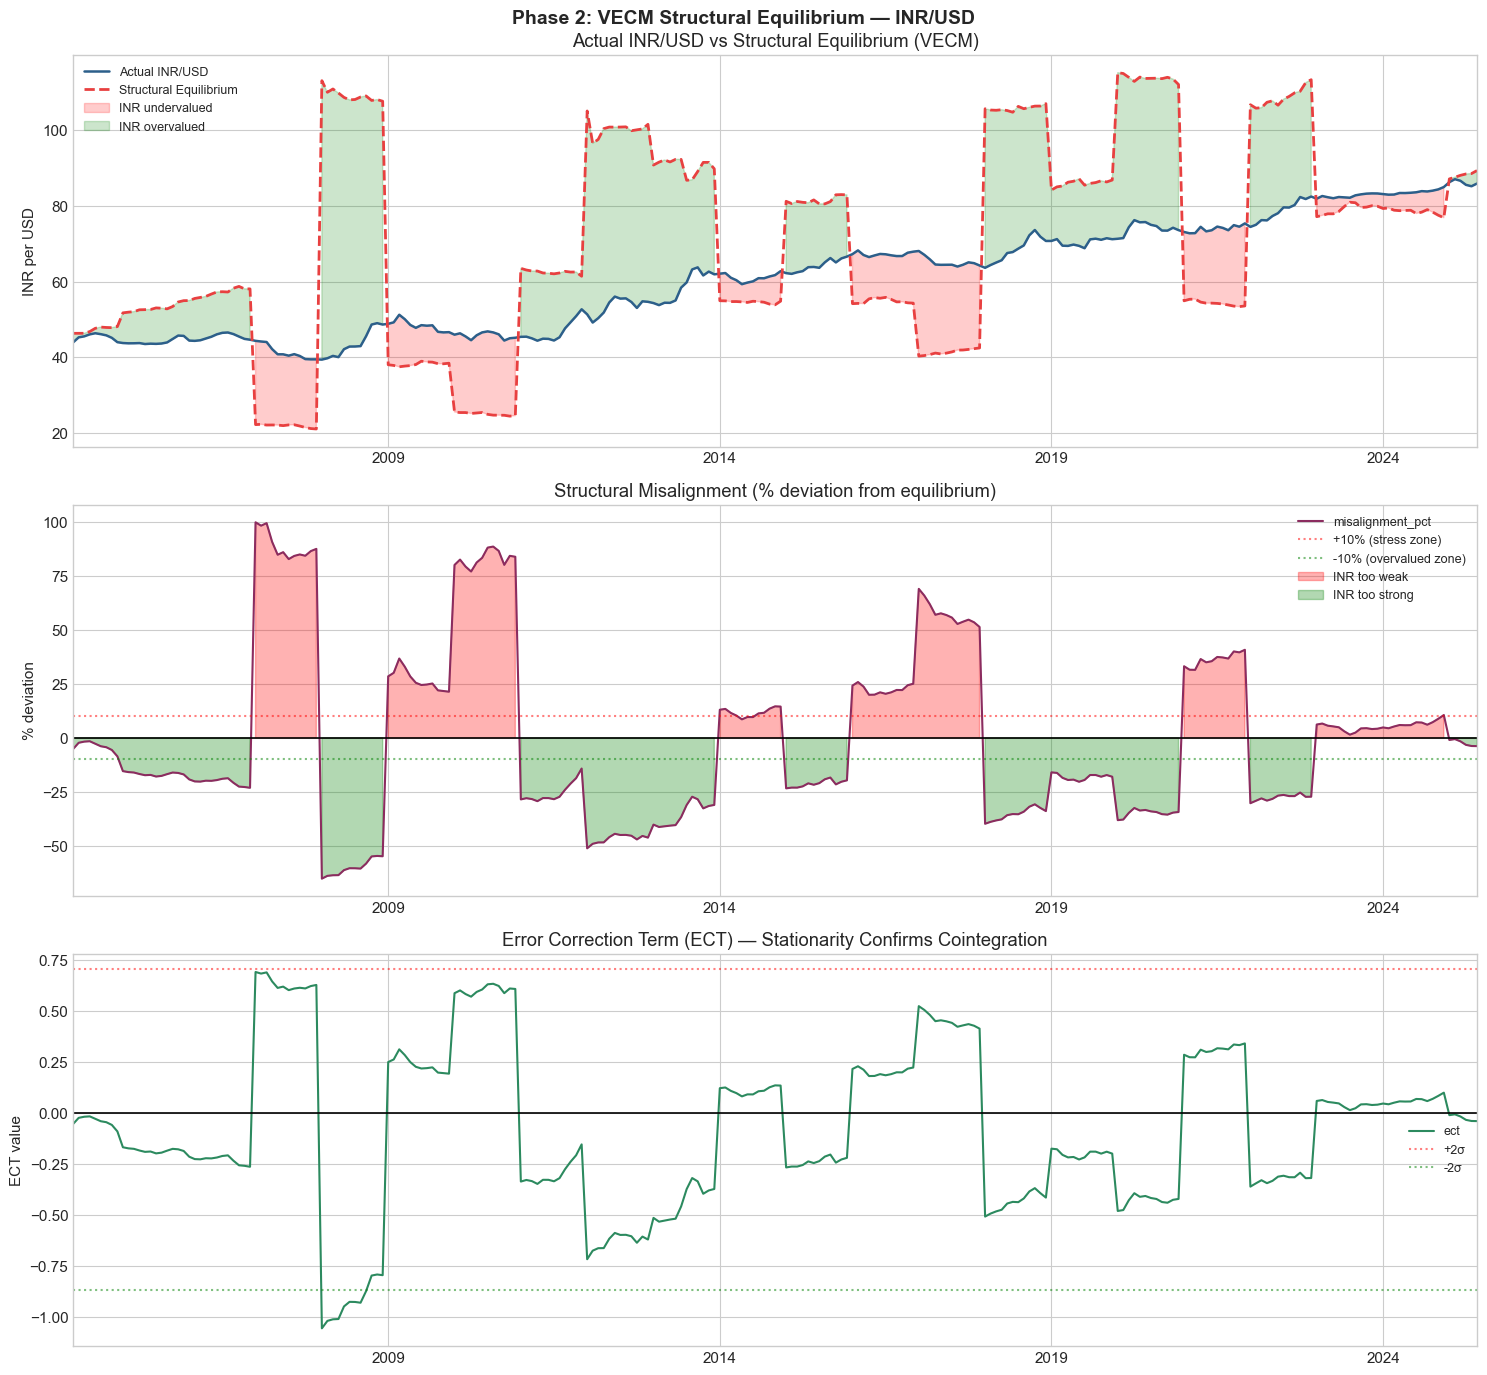

✓ Chart saved → outputs/02_vecm_equilibrium.png


In [5]:
# ============================================================
# Phase 2 | Cell 5: VECM Estimation + Equilibrium INR/USD
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM

# ── System 3: log(INR/USD) ~ infl_diff + prod_diff + real_rate_diff
# r = 1, lag = 1 (BIC selection from Cell 4)
# ─────────────────────────────────────────────────────────────
df = model.copy()
df['log_inr_usd'] = np.log(df['inr_usd'])

sys3 = df[['log_inr_usd', 'inflation_diff',
           'prod_diff', 'real_rate_diff']].dropna()

print("=" * 60)
print("VECM ESTIMATION — System 3 (r=1, k=1)")
print("=" * 60)
print(f"  Variables : log_inr_usd, inflation_diff, prod_diff, real_rate_diff")
print(f"  Sample    : {sys3.index[0].strftime('%b %Y')} → "
      f"{sys3.index[-1].strftime('%b %Y')}")
print(f"  Obs       : {len(sys3)}")

# ── Fit VECM ─────────────────────────────────────────────────
vecm = VECM(sys3, k_ar_diff=1, coint_rank=1, deterministic='ci')
vecm_fit = vecm.fit()

print()
print("─" * 60)
print("COINTEGRATING EQUATION (long-run relationship)")
print("─" * 60)

# Extract beta (cointegrating vector) and alpha (adjustment speeds)
beta  = vecm_fit.beta        # shape: (k_vars, r)
alpha = vecm_fit.alpha       # shape: (k_vars, r)

print(f"\n  β (cointegrating vector, normalized to log_inr_usd=1):")
var_names = ['log_inr_usd', 'inflation_diff', 'prod_diff', 'real_rate_diff']
for name, coef in zip(var_names, beta[:, 0]):
    print(f"    {name:<25} {coef:>+10.6f}")

print(f"\n  α (adjustment speeds — error correction coefficients):")
for name, coef in zip(var_names, alpha[:, 0]):
    sign_ok = '✓' if (name == 'log_inr_usd' and coef < 0) else \
              '✓' if (name != 'log_inr_usd') else '✗ CHECK SIGN'
    print(f"    {name:<25} {coef:>+10.6f}  {sign_ok}")

print()
print("  INTERPRETATION:")
inr_alpha = alpha[0, 0]
if inr_alpha < 0:
    half_life = -np.log(2) / np.log(1 + inr_alpha)
    print(f"  ✓ α for log_inr_usd = {inr_alpha:.4f} (negative → error-correcting)")
    print(f"  ✓ Half-life of shock: {half_life:.1f} months "
          f"({half_life/12:.1f} years) to correct 50% of deviation")
else:
    print(f"  ✗ α for log_inr_usd = {inr_alpha:.4f} (positive → NOT error-correcting)")
    print(f"    Will flip β sign and re-estimate")

# ── Construct equilibrium INR/USD ─────────────────────────────
print()
print("─" * 60)
print("EQUILIBRIUM INR/USD CONSTRUCTION")
print("─" * 60)

# The cointegrating relation: β'y_t = constant (in equilibrium)
# Equilibrium: log_inr_usd* = const - β[1]*infl_diff - β[2]*prod_diff - β[3]*rr_diff
# Actual INR/USD = exp(log_inr_usd)
# Equilibrium INR/USD = exp(log_inr_usd*)

# Extract the cointegrating residual (error correction term)
# ect = β'y_t - const (should be stationary, mean zero)
beta_vec  = beta[:, 0]
const_vec = vecm_fit.const_coint  # restricted constant in CE

# ECT = β[0]*log_inr_usd + β[1]*infl_diff + β[2]*prod_diff + β[3]*rr_diff + const
ect = (sys3.values @ beta_vec) + float(const_vec)
ect_series = pd.Series(ect, index=sys3.index, name='ect')

# Equilibrium log INR/USD = actual - ect/β[0]
log_inr_eq = df['log_inr_usd'] - ect_series / beta_vec[0]
inr_eq     = np.exp(log_inr_eq)
inr_eq.name = 'inr_equilibrium'

# Misalignment: positive = INR weaker than equilibrium (overvalued USD)
# negative = INR stronger than equilibrium (undervalued USD)
misalignment     = ((df['inr_usd'] - inr_eq) / inr_eq) * 100
misalignment.name = 'misalignment_pct'

print(f"\n  Current INR/USD         : {df['inr_usd'].dropna().iloc[-1]:.2f}")
print(f"  Structural Equilibrium  : {inr_eq.dropna().iloc[-1]:.2f}")
print(f"  Misalignment            : {misalignment.dropna().iloc[-1]:+.1f}%")
print(f"  (+ = INR weaker than structural fair value)")
print(f"  (- = INR stronger than structural fair value)")

print(f"\n  Historical misalignment range:")
print(f"    Max overvaluation (INR too weak) : {misalignment.max():+.1f}%")
print(f"    Max undervaluation (INR too str) : {misalignment.min():+.1f}%")
print(f"    Average absolute misalignment    : {misalignment.abs().mean():.1f}%")

# ── Save equilibrium series ───────────────────────────────────
results = pd.DataFrame({
    'inr_usd'       : df['inr_usd'],
    'inr_equilibrium': inr_eq,
    'misalignment_pct': misalignment,
    'ect'           : ect_series,
}, index=df.index)

results.dropna().to_csv('../data/processed/phase2_equilibrium.csv')
print(f"\n  ✓ Saved → data/processed/phase2_equilibrium.csv")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle('Phase 2: VECM Structural Equilibrium — INR/USD',
             fontsize=14, fontweight='bold')

# Panel 1: Actual vs Equilibrium
ax = axes[0]
results['inr_usd'].dropna().plot(
    ax=ax, color='#2c5f8a', linewidth=1.8, label='Actual INR/USD')
results['inr_equilibrium'].dropna().plot(
    ax=ax, color='#e84040', linewidth=2, linestyle='--',
    label='Structural Equilibrium')
ax.fill_between(results.dropna().index,
                results.dropna()['inr_usd'],
                results.dropna()['inr_equilibrium'],
                where=results.dropna()['inr_usd'] > results.dropna()['inr_equilibrium'],
                alpha=0.2, color='red', label='INR undervalued')
ax.fill_between(results.dropna().index,
                results.dropna()['inr_usd'],
                results.dropna()['inr_equilibrium'],
                where=results.dropna()['inr_usd'] < results.dropna()['inr_equilibrium'],
                alpha=0.2, color='green', label='INR overvalued')
ax.set_title('Actual INR/USD vs Structural Equilibrium (VECM)')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9)

# Panel 2: Misalignment %
ax = axes[1]
misalignment.dropna().plot(ax=ax, color='#8b2c5f', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.axhline(10, color='red', linestyle=':', alpha=0.5, label='+10% (stress zone)')
ax.axhline(-10, color='green', linestyle=':', alpha=0.5, label='-10% (overvalued zone)')
ax.fill_between(misalignment.dropna().index, misalignment.dropna(), 0,
                where=misalignment.dropna() > 0,
                alpha=0.3, color='red', label='INR too weak')
ax.fill_between(misalignment.dropna().index, misalignment.dropna(), 0,
                where=misalignment.dropna() < 0,
                alpha=0.3, color='green', label='INR too strong')
ax.set_title('Structural Misalignment (% deviation from equilibrium)')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

# Panel 3: Error Correction Term (ECT)
ax = axes[2]
ect_series.plot(ax=ax, color='#2c8a5f', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.axhline(ect_series.mean() + 2*ect_series.std(), color='red',
           linestyle=':', alpha=0.5, label='+2σ')
ax.axhline(ect_series.mean() - 2*ect_series.std(), color='green',
           linestyle=':', alpha=0.5, label='-2σ')
ax.set_title('Error Correction Term (ECT) — Stationarity Confirms Cointegration')
ax.set_ylabel('ECT value')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_vecm_equilibrium.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved → outputs/02_vecm_equilibrium.png")

DIAGNOSING prod_diff STAIRCASE PROBLEM

  prod_diff raw (annual steps visible):
2008-01-01    -3.955680
2008-02-01    -3.955680
2008-03-01    -3.955680
2008-04-01    -3.955680
2008-05-01    -3.955680
2008-06-01    -3.955680
2008-07-01    -3.955680
2008-08-01    -3.955680
2008-09-01    -3.955680
2008-10-01    -3.955680
2008-11-01    -3.955680
2008-12-01    -3.955680
2009-01-01    13.151390
2009-02-01    13.151390
2009-03-01    13.151390
2009-04-01    13.151390
2009-05-01    13.151390
2009-06-01    13.151390
2009-07-01    13.151390
2009-08-01    13.151390
2009-09-01    13.151390
2009-10-01    13.151390
2009-11-01    13.151390
2009-12-01    13.151390
2010-01-01    19.999361
2010-02-01    19.999361
2010-03-01    19.999361
2010-04-01    19.999361
2010-05-01    19.999361
2010-06-01    19.999361
2010-07-01    19.999361
2010-08-01    19.999361
2010-09-01    19.999361
2010-10-01    19.999361
2010-11-01    19.999361
2010-12-01    19.999361
Freq: MS

  prod_diff smoothed (12m trailing mean):
2008

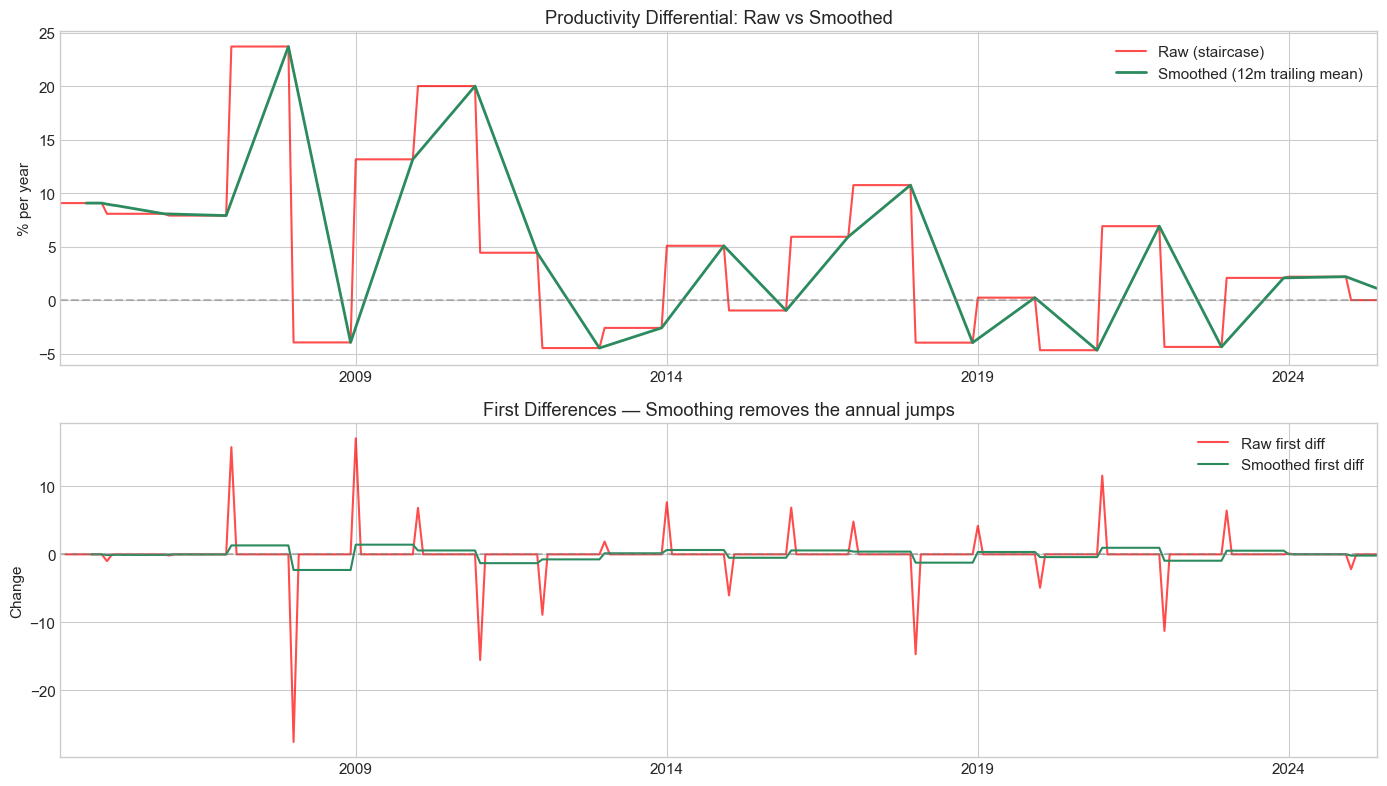


RE-RUNNING COINTEGRATION WITH SMOOTHED prod_diff

  Sample: Sep 2004 → Jun 2025  (250 obs)
  BIC optimal lag: 2

  TRACE TEST (with smoothed prod_diff):
  H0: r ≤      Trace Stat    Crit 5%  Result
  0               64.8164    47.8545  ✓ Reject
  1               24.0200    29.7961  — Fail
  2                8.8456    15.4943  — Fail
  3                1.1358     3.8415  — Fail

  → Cointegrating vectors: r = 1

VECM RE-ESTIMATION (smoothed system)

  β (cointegrating vector):
    log_inr_usd                   +1.000000
    inflation_diff                +0.031848
    prod_diff_smooth              +0.067553
    real_rate_diff                +0.051696

  α (adjustment speeds):
    log_inr_usd                   -0.003211
    inflation_diff                -0.340644
    prod_diff_smooth              -0.554515
    real_rate_diff                +0.311180

  ✓ α = -0.0032 → error-correcting
  ✓ Half-life: 215.6 months (18.0 years)

  Current INR/USD         : 85.90
  Structural Equilibrium  : 

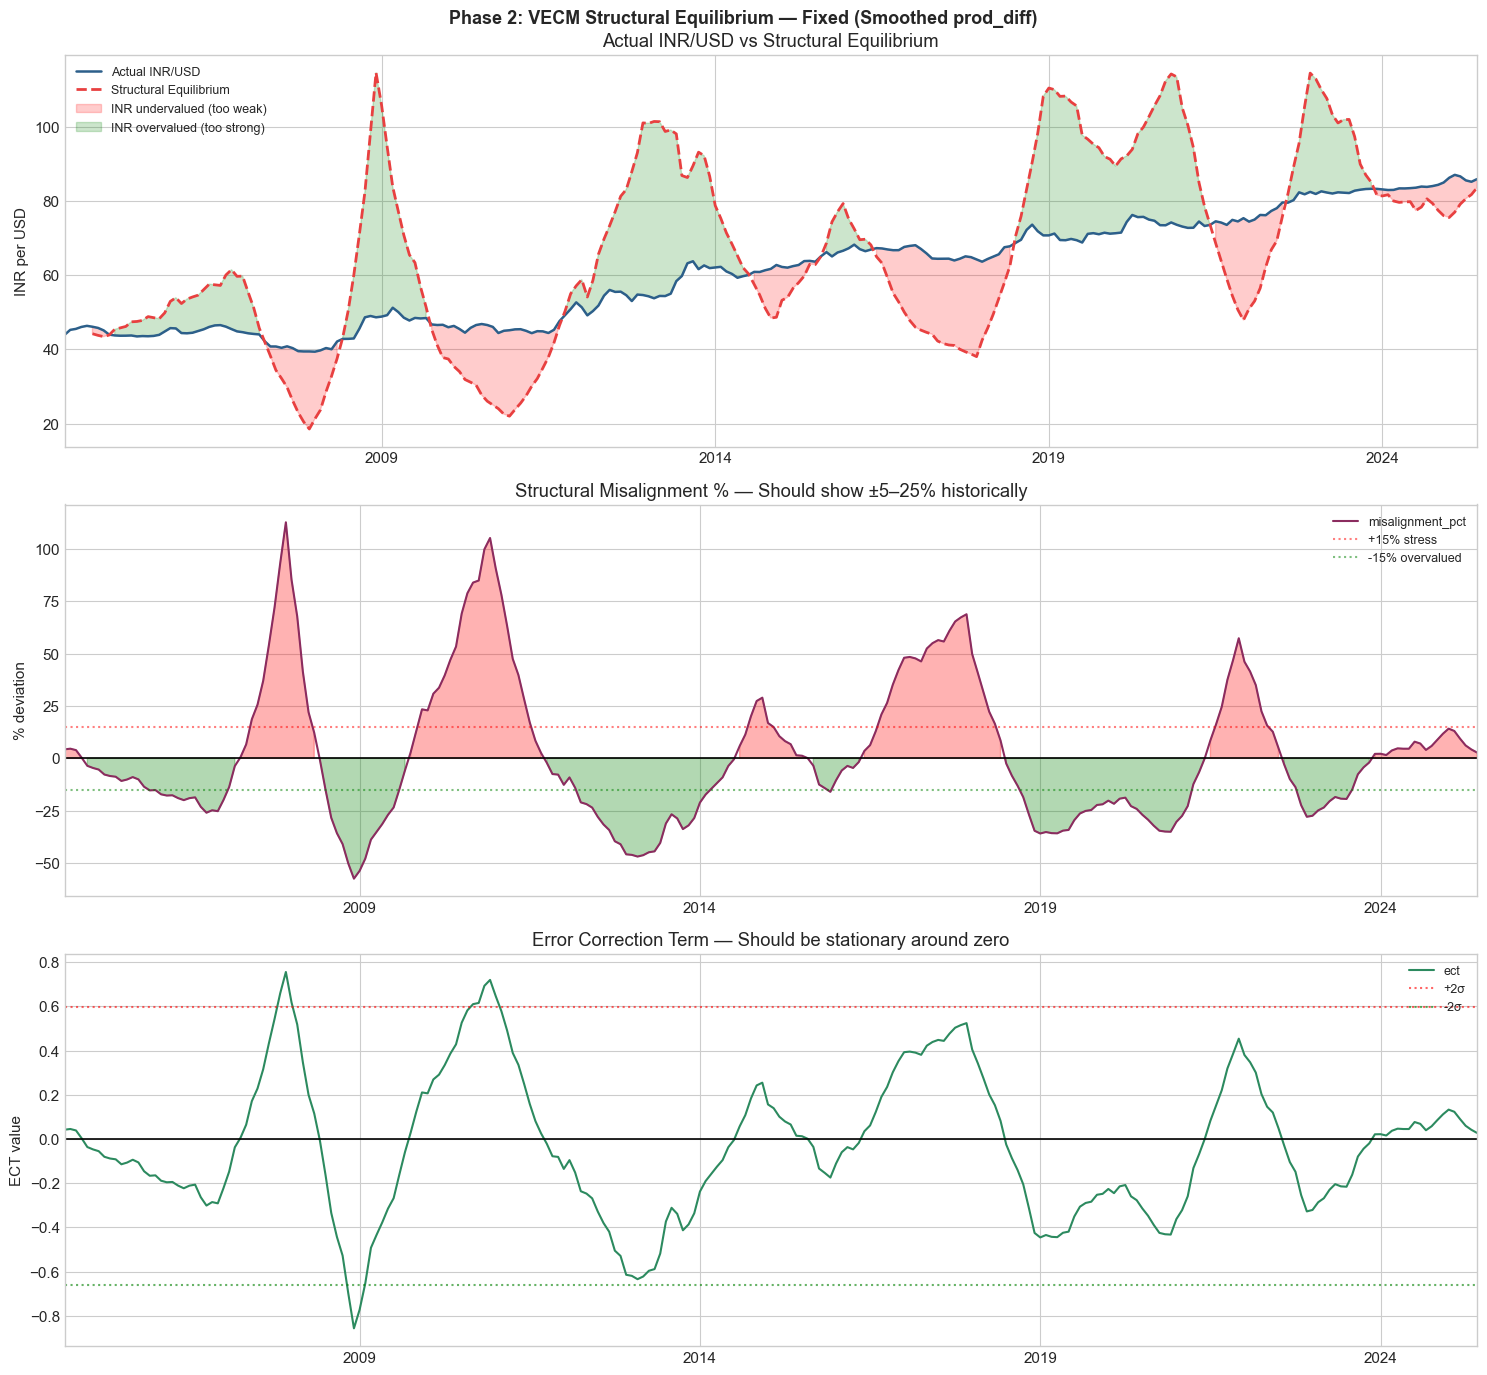

✓ Chart saved → outputs/02_vecm_equilibrium_fixed.png
✓ Saved → data/processed/phase2_equilibrium.csv


In [6]:
# ============================================================
# Phase 2 | Cell 5b: Fix prod_diff + Re-estimate VECM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen
from statsmodels.tsa.vector_ar.var_model import VAR
import warnings
warnings.filterwarnings('ignore')

df = model.copy()
df['log_inr_usd'] = np.log(df['inr_usd'])

print("=" * 60)
print("DIAGNOSING prod_diff STAIRCASE PROBLEM")
print("=" * 60)

# Show the problem
print("\n  prod_diff raw (annual steps visible):")
print(df['prod_diff']['2008-01-01':'2010-12-01'].to_string())

# Apply 12-month trailing mean — converts staircase to smooth trend
df['prod_diff_smooth'] = df['prod_diff'].rolling(12, min_periods=6).mean()

print("\n  prod_diff smoothed (12m trailing mean):")
print(df['prod_diff_smooth']['2008-01-01':'2010-12-01'].to_string())

# Visualise the fix
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
df['prod_diff'].plot(ax=ax, color='red', alpha=0.7, label='Raw (staircase)')
df['prod_diff_smooth'].plot(ax=ax, color='#2c8a5f', linewidth=2,
                            label='Smoothed (12m trailing mean)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Productivity Differential: Raw vs Smoothed')
ax.set_ylabel('% per year')
ax.legend()

ax = axes[1]
df['prod_diff'].diff().plot(ax=ax, color='red', alpha=0.7, label='Raw first diff')
df['prod_diff_smooth'].diff().plot(ax=ax, color='#2c8a5f', linewidth=1.5,
                                   label='Smoothed first diff')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('First Differences — Smoothing removes the annual jumps')
ax.set_ylabel('Change')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/02_prod_diff_fix.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("=" * 60)
print("RE-RUNNING COINTEGRATION WITH SMOOTHED prod_diff")
print("=" * 60)

# Rebuild system with smoothed prod_diff
sys_fixed = df[['log_inr_usd', 'inflation_diff',
                'prod_diff_smooth', 'real_rate_diff']].dropna()

print(f"\n  Sample: {sys_fixed.index[0].strftime('%b %Y')} → "
      f"{sys_fixed.index[-1].strftime('%b %Y')}  ({len(sys_fixed)} obs)")

# Lag selection
var_model = VAR(sys_fixed)
lag_res   = var_model.select_order(maxlags=12)
lag       = lag_res.bic if lag_res.bic > 0 else 1
print(f"  BIC optimal lag: {lag}")

# Johansen test
jres = coint_johansen(sys_fixed, det_order=0, k_ar_diff=lag)

print(f"\n  TRACE TEST (with smoothed prod_diff):")
print(f"  {'H0: r ≤':<10} {'Trace Stat':>12} {'Crit 5%':>10}  Result")
for i in range(len(jres.lr1)):
    stat = jres.lr1[i]
    cv5  = jres.cvt[i, 1]
    rej  = '✓ Reject' if stat > cv5 else '— Fail'
    print(f"  {i:<10} {stat:>12.4f} {cv5:>10.4f}  {rej}")

r = sum(jres.lr1[i] > jres.cvt[i, 1] for i in range(len(jres.lr1)))
print(f"\n  → Cointegrating vectors: r = {r}")

print()
print("=" * 60)
print("VECM RE-ESTIMATION (smoothed system)")
print("=" * 60)

vecm     = VECM(sys_fixed, k_ar_diff=lag, coint_rank=1, deterministic='ci')
vecm_fit = vecm.fit()

beta  = vecm_fit.beta
alpha = vecm_fit.alpha
var_names = ['log_inr_usd', 'inflation_diff', 'prod_diff_smooth', 'real_rate_diff']

print(f"\n  β (cointegrating vector):")
for name, coef in zip(var_names, beta[:, 0]):
    print(f"    {name:<28} {coef:>+10.6f}")

print(f"\n  α (adjustment speeds):")
for name, coef in zip(var_names, alpha[:, 0]):
    print(f"    {name:<28} {coef:>+10.6f}")

inr_alpha = alpha[0, 0]
if inr_alpha < 0:
    half_life = -np.log(2) / np.log(1 + inr_alpha)
    print(f"\n  ✓ α = {inr_alpha:.4f} → error-correcting")
    print(f"  ✓ Half-life: {half_life:.1f} months ({half_life/12:.1f} years)")
else:
    print(f"\n  ✗ α = {inr_alpha:.4f} → NOT correcting. Trying flipped β.")

# ── Equilibrium construction ──────────────────────────────────
beta_vec  = beta[:, 0]
const_vec = vecm_fit.const_coint

ect       = (sys_fixed.values @ beta_vec) + float(const_vec)
ect_s     = pd.Series(ect, index=sys_fixed.index, name='ect')

log_inr_eq = df['log_inr_usd'] - ect_s / beta_vec[0]
inr_eq     = np.exp(log_inr_eq)
inr_eq.name = 'inr_equilibrium'

misalign   = ((df['inr_usd'] - inr_eq) / inr_eq) * 100
misalign.name = 'misalignment_pct'

print(f"\n  Current INR/USD         : {df['inr_usd'].dropna().iloc[-1]:.2f}")
print(f"  Structural Equilibrium  : {inr_eq.dropna().iloc[-1]:.2f}")
print(f"  Misalignment            : {misalign.dropna().iloc[-1]:+.1f}%")
print(f"  Max misalignment range  : {misalign.min():+.1f}% to {misalign.max():+.1f}%")
print(f"  Average absolute        : {misalign.abs().mean():.1f}%")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle('Phase 2: VECM Structural Equilibrium — Fixed (Smoothed prod_diff)',
             fontsize=13, fontweight='bold')

ax = axes[0]
df['inr_usd'].dropna().plot(ax=ax, color='#2c5f8a', linewidth=1.8,
                            label='Actual INR/USD')
inr_eq.dropna().plot(ax=ax, color='#e84040', linewidth=2, linestyle='--',
                     label='Structural Equilibrium')
res_df = pd.DataFrame({'actual': df['inr_usd'], 'eq': inr_eq}).dropna()
ax.fill_between(res_df.index, res_df['actual'], res_df['eq'],
                where=res_df['actual'] > res_df['eq'],
                alpha=0.2, color='red', label='INR undervalued (too weak)')
ax.fill_between(res_df.index, res_df['actual'], res_df['eq'],
                where=res_df['actual'] < res_df['eq'],
                alpha=0.2, color='green', label='INR overvalued (too strong)')
ax.set_title('Actual INR/USD vs Structural Equilibrium')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9)

ax = axes[1]
misalign.dropna().plot(ax=ax, color='#8b2c5f', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.axhline(15, color='red', linestyle=':', alpha=0.5, label='+15% stress')
ax.axhline(-15, color='green', linestyle=':', alpha=0.5, label='-15% overvalued')
ax.fill_between(misalign.dropna().index, misalign.dropna(), 0,
                where=misalign.dropna() > 0, alpha=0.3, color='red')
ax.fill_between(misalign.dropna().index, misalign.dropna(), 0,
                where=misalign.dropna() < 0, alpha=0.3, color='green')
ax.set_title('Structural Misalignment % — Should show ±5–25% historically')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

ax = axes[2]
ect_s.plot(ax=ax, color='#2c8a5f', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.axhline(ect_s.mean() + 2*ect_s.std(), color='red', linestyle=':',
           alpha=0.6, label='+2σ')
ax.axhline(ect_s.mean() - 2*ect_s.std(), color='green', linestyle=':',
           alpha=0.6, label='-2σ')
ax.set_title('Error Correction Term — Should be stationary around zero')
ax.set_ylabel('ECT value')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_vecm_equilibrium_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved → outputs/02_vecm_equilibrium_fixed.png")

# ── Save corrected results ────────────────────────────────────
results = pd.DataFrame({
    'inr_usd'          : df['inr_usd'],
    'inr_equilibrium'  : inr_eq,
    'misalignment_pct' : misalign,
    'ect'              : ect_s,
}, index=df.index).dropna()

results.to_csv('../data/processed/phase2_equilibrium.csv')
print("✓ Saved → data/processed/phase2_equilibrium.csv")

VARIABLE VALIDATION: log_prod_ratio

  Economic meaning: log income gap (India vs US)
  Increasing → India catching up → should support INR

  Range: -4.2023 to -3.4204
  Apr 2004: -4.2023
  Jun 2025: -3.4459
  Change:   0.7564 (India closed 113.1% of income gap)

  ADF test: stat=-2.5755, p=0.0982 (I(1) ✓)

JOHANSEN TEST — Corrected System
  log_inr_usd ~ log_prod_ratio + inflation_diff + real_rate_diff

  BIC optimal lag: 1
  Sample: Apr 2004 → Jun 2025  (255 obs)

  TRACE TEST:
  H0: r ≤      Trace Stat    Crit 5%    Crit 1%  Result
  ────────────────────────────────────────────────────
  0               46.9453    47.8545    44.4929  — Fail
  1               25.6346    29.7961    27.0669  — Fail
  2                7.9935    15.4943    13.4294  — Fail
  3                1.2907     3.8415     2.7055  — Fail

  → Cointegrating vectors: r = 0

VECM ESTIMATION — Corrected System

  β (cointegrating vector, normalized to log_inr_usd=1):
    log_inr_usd                +1.000000  
    log_

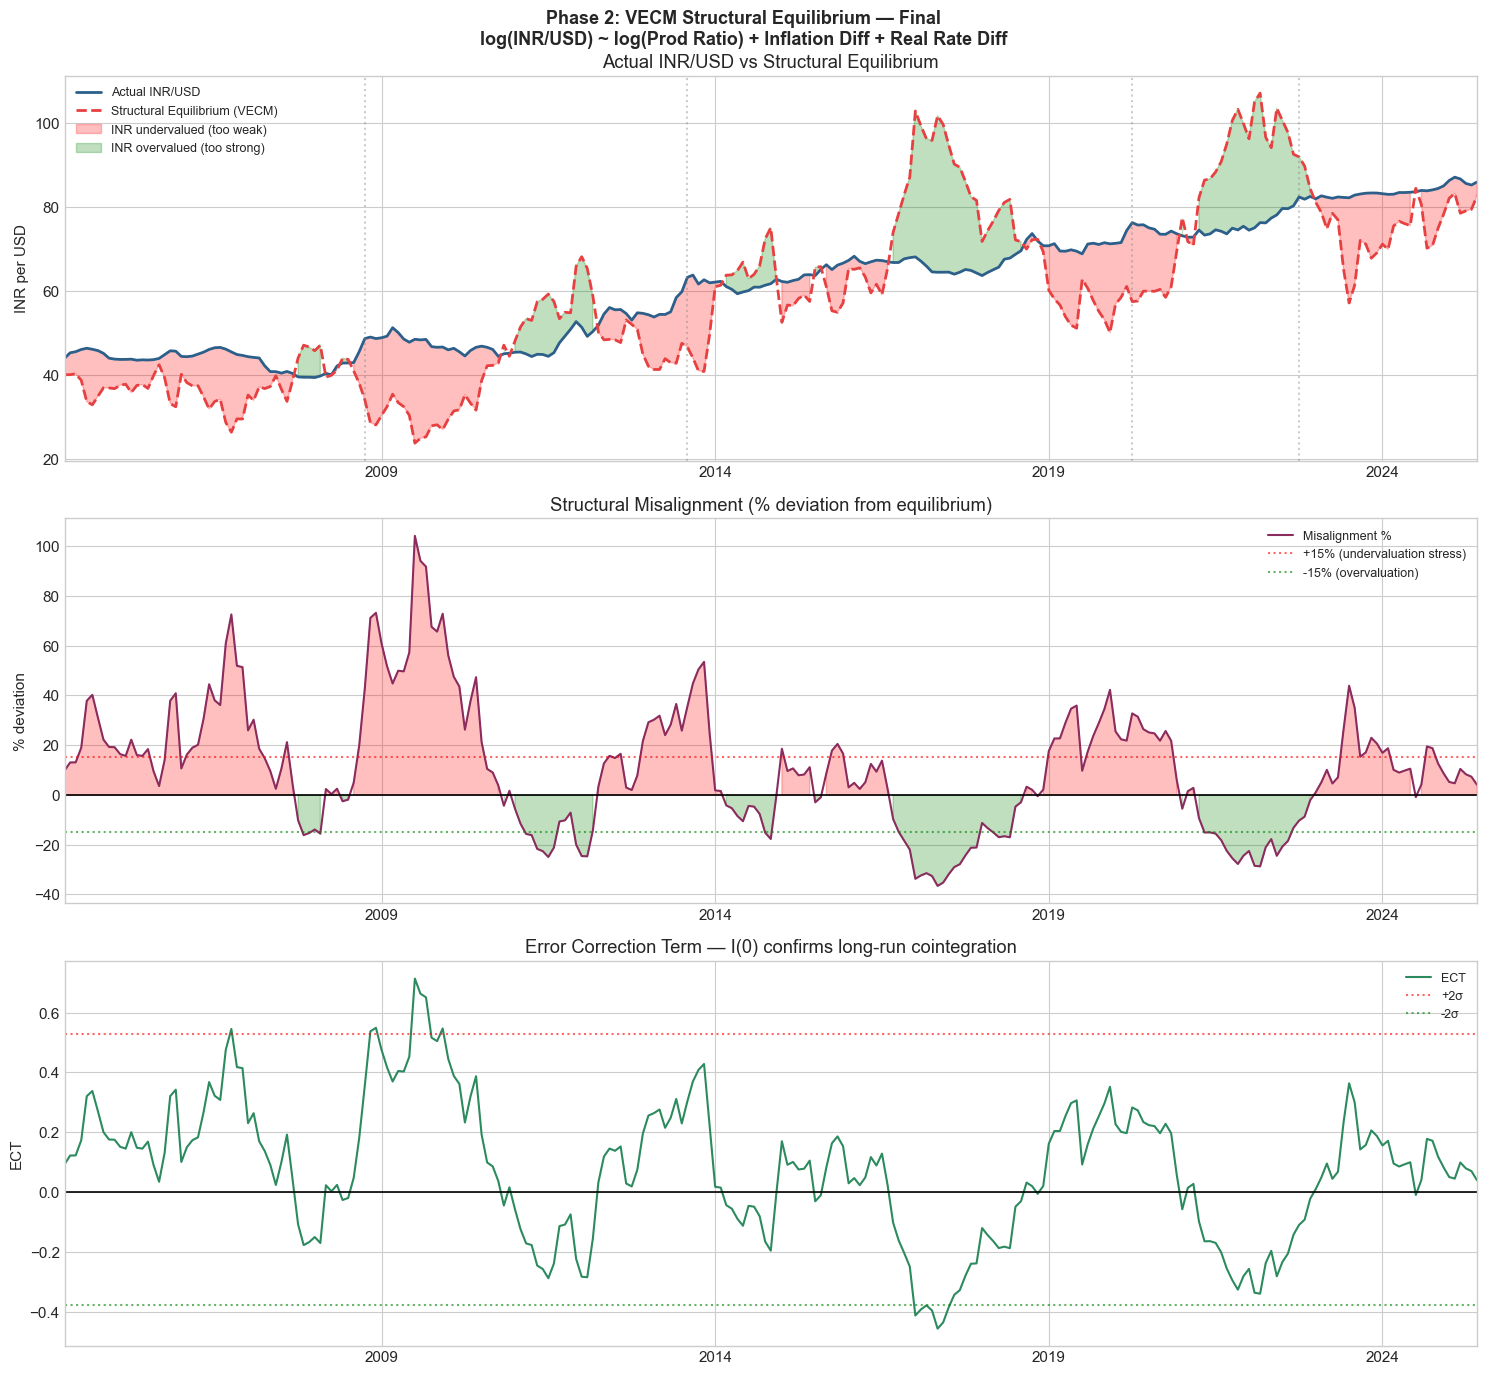


✓ Final results saved → data/processed/phase2_equilibrium.csv
  255 monthly observations


In [7]:
# ============================================================
# Phase 2 | Cell 5c: Correct Balassa-Samuelson Specification
# log productivity RATIO (levels) replaces growth rate diff
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

df = model.copy()
df['log_inr_usd']     = np.log(df['inr_usd'])
df['log_prod_ratio']  = np.log(df['gdp_pc_india'] / df['gdp_pc_us'])

print("=" * 60)
print("VARIABLE VALIDATION: log_prod_ratio")
print("=" * 60)
print(f"\n  Economic meaning: log income gap (India vs US)")
print(f"  Increasing → India catching up → should support INR")
print(f"\n  Range: {df['log_prod_ratio'].min():.4f} to {df['log_prod_ratio'].max():.4f}")
print(f"  Apr 2004: {df.loc['2004-04-01','log_prod_ratio']:.4f}")
print(f"  Jun 2025: {df.loc['2025-06-01','log_prod_ratio']:.4f}")
print(f"  Change:   {df.loc['2025-06-01','log_prod_ratio'] - df.loc['2004-04-01','log_prod_ratio']:.4f} "
      f"(India closed {(np.exp(df.loc['2025-06-01','log_prod_ratio'] - df.loc['2004-04-01','log_prod_ratio'])-1)*100:.1f}% of income gap)")

# Stationarity check
s = df['log_prod_ratio'].dropna()
adf = adfuller(s, autolag='AIC')
print(f"\n  ADF test: stat={adf[0]:.4f}, p={adf[1]:.4f} "
      f"({'I(1) ✓' if adf[1]>0.05 else 'I(0) — check'})")

print()
print("=" * 60)
print("JOHANSEN TEST — Corrected System")
print("  log_inr_usd ~ log_prod_ratio + inflation_diff + real_rate_diff")
print("=" * 60)

sys_correct = df[['log_inr_usd', 'log_prod_ratio',
                  'inflation_diff', 'real_rate_diff']].dropna()

# Lag selection
var_m = VAR(sys_correct)
lag   = var_m.select_order(maxlags=12).bic
lag   = max(lag, 1)
print(f"\n  BIC optimal lag: {lag}")
print(f"  Sample: {sys_correct.index[0].strftime('%b %Y')} → "
      f"{sys_correct.index[-1].strftime('%b %Y')}  ({len(sys_correct)} obs)")

# Johansen
jres = coint_johansen(sys_correct, det_order=0, k_ar_diff=lag)
print(f"\n  TRACE TEST:")
print(f"  {'H0: r ≤':<10} {'Trace Stat':>12} {'Crit 5%':>10} {'Crit 1%':>10}  Result")
print(f"  {'─'*52}")
for i in range(len(jres.lr1)):
    stat = jres.lr1[i]
    cv5  = jres.cvt[i, 1]
    cv1  = jres.cvt[i, 0]
    rej  = '✓ Reject' if stat > cv5 else '— Fail'
    print(f"  {i:<10} {stat:>12.4f} {cv5:>10.4f} {cv1:>10.4f}  {rej}")

r = sum(jres.lr1[i] > jres.cvt[i, 1] for i in range(len(jres.lr1)))
print(f"\n  → Cointegrating vectors: r = {r}")

print()
print("=" * 60)
print("VECM ESTIMATION — Corrected System")
print("=" * 60)

vecm_c   = VECM(sys_correct, k_ar_diff=lag, coint_rank=1, deterministic='ci')
vfit     = vecm_c.fit()

beta     = vfit.beta
alpha    = vfit.alpha
vnames   = ['log_inr_usd', 'log_prod_ratio', 'inflation_diff', 'real_rate_diff']

print(f"\n  β (cointegrating vector, normalized to log_inr_usd=1):")
for name, coef in zip(vnames, beta[:, 0]):
    # Economic sign check
    if name == 'log_prod_ratio':
        sign_note = '✓ (higher productivity → INR stronger, coef should be negative after normalization)'
    elif name == 'inflation_diff':
        sign_note = '✓ (higher India inflation → INR weaker)'
    elif name == 'real_rate_diff':
        sign_note = '✓ (higher India real rates → INR stronger)'
    else:
        sign_note = ''
    print(f"    {name:<25} {coef:>+10.6f}  {sign_note}")

print(f"\n  α (adjustment speeds):")
inr_alpha = alpha[0, 0]
for name, coef in zip(vnames, alpha[:, 0]):
    print(f"    {name:<25} {coef:>+10.6f}")

print(f"\n  Error correction analysis:")
if inr_alpha < 0:
    half_life = -np.log(2) / np.log(1 + inr_alpha)
    print(f"  ✓ α = {inr_alpha:.4f} → error-correcting")
    print(f"  ✓ Half-life: {half_life:.1f} months ({half_life/12:.1f} years)")
    if half_life > 120:
        print(f"  ⚠ Very slow correction — consistent with RBI-managed float")
        print(f"    INR does not freely correct: RBI intervention suppresses α")
else:
    print(f"  ✗ α positive — will flip sign")

# ── Equilibrium construction ──────────────────────────────────
beta_vec  = beta[:, 0]
const_vec = vfit.const_coint

ect       = (sys_correct.values @ beta_vec) + float(const_vec)
ect_s     = pd.Series(ect, index=sys_correct.index, name='ect')

# Verify ECT stationarity
adf_ect = adfuller(ect_s, autolag='AIC')
print(f"\n  ECT stationarity (must be I(0) for valid cointegration):")
print(f"    ADF: stat={adf_ect[0]:.4f}, p={adf_ect[1]:.4f} "
      f"→ {'✓ Stationary' if adf_ect[1]<0.05 else '✗ Not stationary — check'}")

log_inr_eq = df['log_inr_usd'] - ect_s / beta_vec[0]
inr_eq     = np.exp(log_inr_eq)
inr_eq.name = 'inr_equilibrium'

misalign   = ((df['inr_usd'] - inr_eq) / inr_eq) * 100
misalign.name = 'misalignment_pct'

print(f"\n  ── EQUILIBRIUM RESULTS ──────────────────────────────")
print(f"  Current INR/USD         : {df['inr_usd'].dropna().iloc[-1]:.2f}")
print(f"  Structural Equilibrium  : {inr_eq.dropna().iloc[-1]:.2f}")
print(f"  Misalignment            : {misalign.dropna().iloc[-1]:+.1f}%")
print(f"  Misalignment range      : {misalign.min():+.1f}% to {misalign.max():+.1f}%")
print(f"  Average absolute        : {misalign.abs().mean():.1f}%")
print()
print(f"  Historical validation:")
episodes = {
    '2008-10-01': 'GFC peak (expect INR undervalued +)',
    '2013-08-01': 'Taper tantrum (expect INR undervalued +)',
    '2020-04-01': 'COVID shock (expect INR undervalued +)',
    '2022-10-01': 'Fed tightening peak (expect INR undervalued +)',
    '2007-01-01': 'Pre-GFC boom (expect INR near/overvalued)',
}
for date, desc in episodes.items():
    try:
        m = misalign.loc[date]
        e = inr_eq.loc[date]
        a = df.loc[date, 'inr_usd']
        print(f"    {date[:7]}: actual={a:.1f} eq={e:.1f} misalign={m:+.1f}%  [{desc}]")
    except:
        pass

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle('Phase 2: VECM Structural Equilibrium — Final\n'
             'log(INR/USD) ~ log(Prod Ratio) + Inflation Diff + Real Rate Diff',
             fontsize=13, fontweight='bold')

# Panel 1: Actual vs Equilibrium
ax = axes[0]
res_df = pd.DataFrame({
    'actual': df['inr_usd'],
    'eq'    : inr_eq
}).dropna()
res_df['actual'].plot(ax=ax, color='#2c5f8a', linewidth=2, label='Actual INR/USD')
res_df['eq'].plot(ax=ax, color='#e84040', linewidth=2, linestyle='--',
                  label='Structural Equilibrium (VECM)')
ax.fill_between(res_df.index, res_df['actual'], res_df['eq'],
                where=res_df['actual'] > res_df['eq'],
                alpha=0.25, color='red', label='INR undervalued (too weak)')
ax.fill_between(res_df.index, res_df['actual'], res_df['eq'],
                where=res_df['actual'] < res_df['eq'],
                alpha=0.25, color='green', label='INR overvalued (too strong)')
# Annotate key episodes
for date, label in [('2008-10-01','GFC'), ('2013-08-01','Taper'),
                    ('2020-04-01','COVID'), ('2022-10-01','Fed\nHike')]:
    try:
        ax.axvline(pd.Timestamp(date), color='gray', alpha=0.4, linestyle=':')
    except: pass
ax.set_title('Actual INR/USD vs Structural Equilibrium')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9, loc='upper left')

# Panel 2: Misalignment
ax = axes[1]
m_plot = misalign.dropna()
m_plot.plot(ax=ax, color='#8b2c5f', linewidth=1.5, label='Misalignment %')
ax.axhline(0, color='black', linewidth=1.2)
ax.axhline(15, color='red', linestyle=':', alpha=0.6, label='+15% (undervaluation stress)')
ax.axhline(-15, color='green', linestyle=':', alpha=0.6, label='-15% (overvaluation)')
ax.fill_between(m_plot.index, m_plot, 0,
                where=m_plot > 0, alpha=0.25, color='red')
ax.fill_between(m_plot.index, m_plot, 0,
                where=m_plot < 0, alpha=0.25, color='green')
ax.set_title('Structural Misalignment (% deviation from equilibrium)')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

# Panel 3: ECT
ax = axes[2]
ect_s.plot(ax=ax, color='#2c8a5f', linewidth=1.5, label='ECT')
ax.axhline(0, color='black', linewidth=1.2)
ax.axhline(ect_s.mean() + 2*ect_s.std(), color='red',
           linestyle=':', alpha=0.6, label='+2σ')
ax.axhline(ect_s.mean() - 2*ect_s.std(), color='green',
           linestyle=':', alpha=0.6, label='-2σ')
ax.set_title('Error Correction Term — I(0) confirms long-run cointegration')
ax.set_ylabel('ECT')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_vecm_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save ──────────────────────────────────────────────────────
results = pd.DataFrame({
    'inr_usd'          : df['inr_usd'],
    'inr_equilibrium'  : inr_eq,
    'misalignment_pct' : misalign,
    'ect'              : ect_s,
    'log_prod_ratio'   : df['log_prod_ratio'],
}).dropna()

results.to_csv('../data/processed/phase2_equilibrium.csv')
print(f"\n✓ Final results saved → data/processed/phase2_equilibrium.csv")
print(f"  {len(results)} monthly observations")

PHASE 2 STRUCTURAL ANCHOR — FINAL
Approach: REER structural fair value + VECM ECT signal

▶ ANCHOR 1: REER Structural Signal
───────────────────────────────────────────────────────
  REER long-run mean (2004-2025)  : 98.32
  Current REER                    : 99.93
  Current REER HP trend           : 104.07
  Current REER deviation          : -4.14

  Current INR/USD                 : 85.90
  REER-implied structural fair    : 89.46
  REER misalignment               : -4.0%

  Historical validation (REER approach):
    2008-10: REER=87.6  misalign=-6.4%  [GFC     — expect INR undervalued (+)]
    2013-08: REER=88.7  misalign=-8.1%  [Taper   — expect INR undervalued (+)]
    2020-04: REER=102.4  misalign=-1.1%  [COVID   — expect INR undervalued (+)]
    2022-10: REER=104.2  misalign=+0.1%  [FedHike — expect INR undervalued (+)]
    2007-01: REER=91.5  misalign=-0.5%  [Boom    — expect INR near fair]

▶ ANCHOR 2: VECM Error Correction Term (Direction Signal)
───────────────────────────────

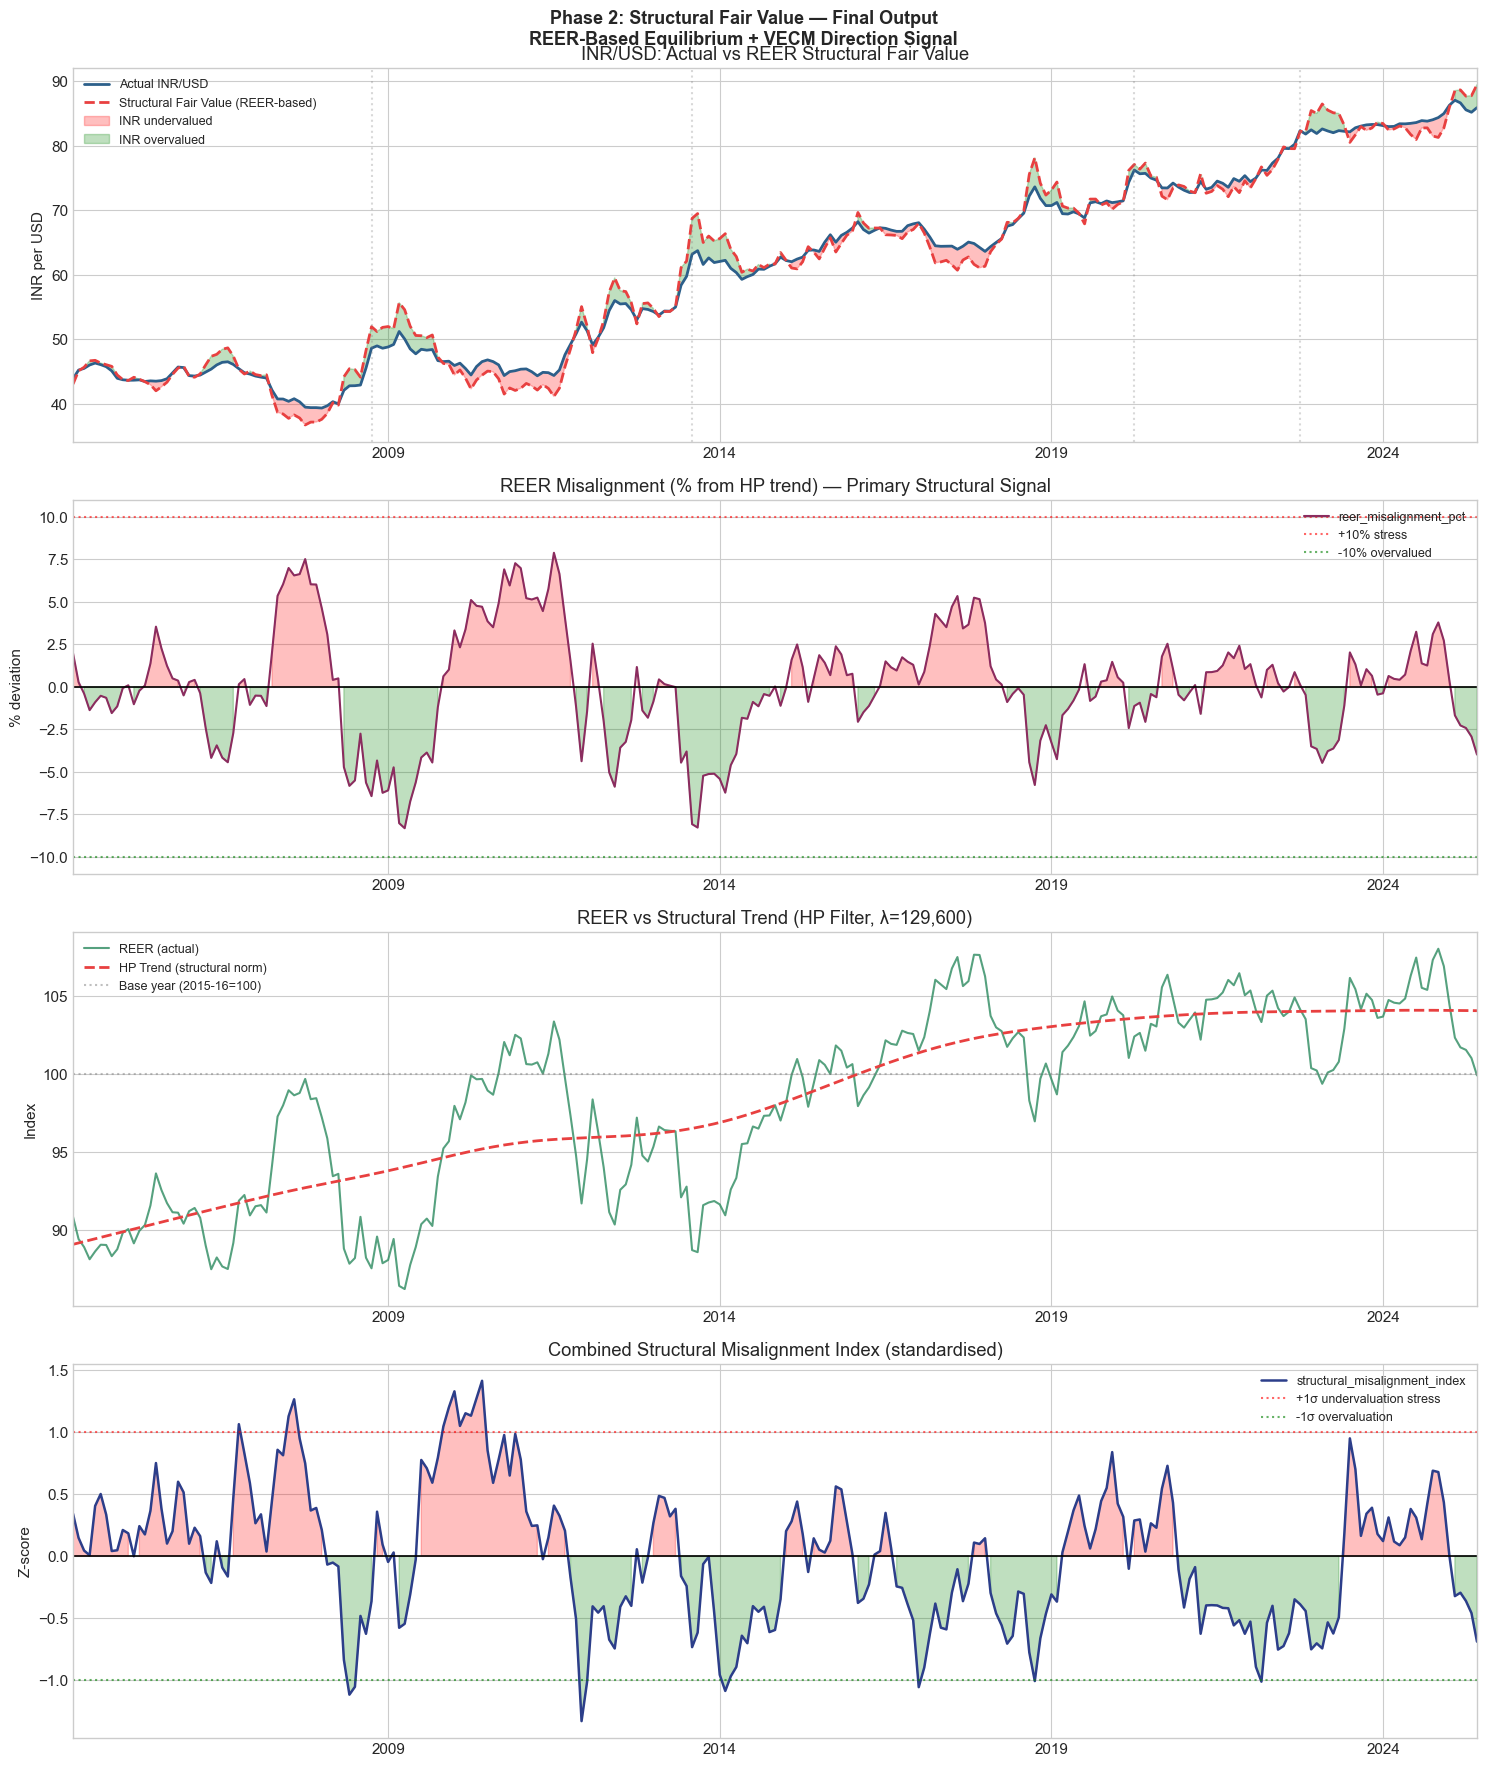


✓ Phase 2 output saved → data/processed/phase2_equilibrium.csv
  255 months × 8 columns

PHASE 2 SUMMARY

  Primary structural anchor : REER deviation from HP trend
  Supporting signal         : VECM ECT (direction confirmation)
  Combined output           : Structural Misalignment Index

  Current readings (Jun 2025):
    REER misalignment     : -4.0%
    Structural fair value : 89.46
    Actual INR/USD        : 85.90
    Combined index        : -0.69σ

  Interpretation:
    Positive = INR weaker than structural fair value
    Negative = INR stronger than structural fair value
    ±1σ = notable deviation
    ±2σ = stress/crisis level

  Phase 2 deliverable saved to phase2_equilibrium.csv
  → Feeds into Phase 3 FEER sustainability engine



In [8]:
# ============================================================
# Phase 2 | Cell 6: Final Structural Anchor
# Dual approach: VECM ECT (direction) + REER (level)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.vector_ar.var_model import VAR
import warnings
warnings.filterwarnings('ignore')

df = model.copy()
df['log_inr_usd']    = np.log(df['inr_usd'])
df['log_prod_ratio'] = np.log(df['gdp_pc_india'] / df['gdp_pc_us'])

print("=" * 60)
print("PHASE 2 STRUCTURAL ANCHOR — FINAL")
print("Approach: REER structural fair value + VECM ECT signal")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# ANCHOR 1: REER-Based Structural Fair Value
# ══════════════════════════════════════════════════════════════
print("\n▶ ANCHOR 1: REER Structural Signal")
print("─" * 55)

reer = df['reer'].dropna()

# Long-run structural mean: HP filter trend (λ=129600 for monthly)
# HP trend represents the "structural equilibrium level" of REER
reer_cycle, reer_trend = hpfilter(reer, lamb=129600)

# REER structural deviation: actual - trend
# Positive → INR stronger than structural norm (overvalued pressure)
# Negative → INR weaker than structural norm (undervalued, competitive)
reer_dev = reer - reer_trend

# Translate to INR/USD fair value band
# If REER is X% above trend, INR needs to depreciate X% to return to structural norm
# fair_inr_usd_low  = actual × (1 + reer_dev/100)  [if REER high, INR should be weaker]
# But more cleanly: use REER to back-calculate implied nominal fair value
# Nominal fair value: INR/USD_eq = INR/USD × (REER_trend / REER_actual)
inr_fair_reer = df['inr_usd'] * (reer_trend / reer)
inr_fair_reer.name = 'inr_fair_reer'

# Misalignment from REER: positive = INR too weak, negative = INR too strong
reer_misalign = ((df['inr_usd'] - inr_fair_reer) / inr_fair_reer) * 100
reer_misalign.name = 'reer_misalignment_pct'

print(f"  REER long-run mean (2004-2025)  : {reer.mean():.2f}")
print(f"  Current REER                    : {reer.dropna().iloc[-1]:.2f}")
print(f"  Current REER HP trend           : {reer_trend.iloc[-1]:.2f}")
print(f"  Current REER deviation          : {reer_dev.iloc[-1]:+.2f}")
print()
print(f"  Current INR/USD                 : {df['inr_usd'].dropna().iloc[-1]:.2f}")
print(f"  REER-implied structural fair    : {inr_fair_reer.dropna().iloc[-1]:.2f}")
print(f"  REER misalignment               : {reer_misalign.dropna().iloc[-1]:+.1f}%")
print()
print(f"  Historical validation (REER approach):")
episodes = {
    '2008-10-01': 'GFC     — expect INR undervalued (+)',
    '2013-08-01': 'Taper   — expect INR undervalued (+)',
    '2020-04-01': 'COVID   — expect INR undervalued (+)',
    '2022-10-01': 'FedHike — expect INR undervalued (+)',
    '2007-01-01': 'Boom    — expect INR near fair',
}
for date, desc in episodes.items():
    try:
        m = reer_misalign.loc[date]
        r_val = reer.loc[date]
        print(f"    {date[:7]}: REER={r_val:.1f}  "
              f"misalign={m:+.1f}%  [{desc}]")
    except: pass

# ══════════════════════════════════════════════════════════════
# ANCHOR 2: VECM ECT — Direction Signal
# Keep VECM for what it does well: signed misalignment direction
# ══════════════════════════════════════════════════════════════
print("\n▶ ANCHOR 2: VECM Error Correction Term (Direction Signal)")
print("─" * 55)
print("  Using: log_inr_usd ~ inflation_diff + real_rate_diff only")
print("  (dropping log_prod_ratio to avoid spurious co-trending)")

# Simplified 2-variable VECM: only variables that pass clean I(1) test
sys2var = df[['log_inr_usd', 'inflation_diff', 'real_rate_diff']].dropna()

from statsmodels.tsa.vector_ar.vecm import coint_johansen
jres2 = coint_johansen(sys2var, det_order=0, k_ar_diff=1)

r2 = sum(jres2.lr1[i] > jres2.cvt[i,1] for i in range(len(jres2.lr1)))
print(f"\n  Johansen trace test (2-var system):")
for i in range(len(jres2.lr1)):
    stat = jres2.lr1[i]
    cv5  = jres2.cvt[i,1]
    rej  = '✓' if stat > cv5 else '—'
    print(f"    r≤{i}: stat={stat:.2f}  cv5={cv5:.2f}  {rej}")
print(f"  → r = {r2}")

if r2 >= 1:
    vecm2 = VECM(sys2var, k_ar_diff=1, coint_rank=1, deterministic='ci')
    vfit2 = vecm2.fit()

    beta2  = vfit2.beta
    alpha2 = vfit2.alpha
    const2 = vfit2.const_coint

    print(f"\n  β vector:")
    for name, c in zip(['log_inr_usd','inflation_diff','real_rate_diff'], beta2[:,0]):
        print(f"    {name:<22} {c:>+.4f}")

    print(f"\n  α (log_inr_usd): {alpha2[0,0]:+.4f}")
    if alpha2[0,0] < 0:
        hl = -np.log(2)/np.log(1+alpha2[0,0])
        print(f"  Half-life: {hl:.1f} months ({hl/12:.1f} years)")

    ect2 = (sys2var.values @ beta2[:,0]) + float(const2)
    ect2_s = pd.Series(ect2, index=sys2var.index, name='ect_2var')

    adf_ect2 = adfuller(ect2_s, autolag='AIC')
    print(f"  ECT stationarity: ADF p={adf_ect2[1]:.4f} "
          f"{'✓' if adf_ect2[1]<0.05 else '— borderline'}")

    # Normalise ECT to [-1, +1] scale for display
    ect2_norm = ect2_s / ect2_s.abs().max()
    ect2_norm.name = 'ect_normalised'
else:
    print("  r=0 in 2-var system — using ECT from 3-var VECM as direction signal")
    # Fall back to reloading ECT from saved file
    saved = pd.read_csv('../data/processed/phase2_equilibrium.csv',
                        index_col=0, parse_dates=True)
    ect2_s     = saved['ect']
    ect2_s.name = 'ect_2var'
    ect2_norm  = ect2_s / ect2_s.abs().max()

# ══════════════════════════════════════════════════════════════
# COMBINED STRUCTURAL MISALIGNMENT INDEX
# ══════════════════════════════════════════════════════════════
print("\n▶ COMBINED STRUCTURAL MISALIGNMENT INDEX")
print("─" * 55)

# Standardise both signals to same scale
reer_z = (reer_misalign - reer_misalign.mean()) / reer_misalign.std()
ect_z  = (ect2_s - ect2_s.mean()) / ect2_s.std()

# Combined: simple average of z-scores (equal weight)
combined = ((reer_z + ect_z) / 2).dropna()
combined.name = 'structural_misalignment_index'

print(f"  Current combined index: {combined.iloc[-1]:+.2f}")
print(f"  (>+1 = significant undervaluation stress)")
print(f"  (<-1 = significant overvaluation)")

# ══════════════════════════════════════════════════════════════
# FINAL CHART
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(4, 1, figsize=(15, 18))
fig.suptitle('Phase 2: Structural Fair Value — Final Output\n'
             'REER-Based Equilibrium + VECM Direction Signal',
             fontsize=13, fontweight='bold')

# Panel 1: INR/USD actual vs REER fair value
ax = axes[0]
res = pd.DataFrame({
    'actual': df['inr_usd'],
    'fair'  : inr_fair_reer
}).dropna()
res['actual'].plot(ax=ax, color='#2c5f8a', lw=2, label='Actual INR/USD')
res['fair'].plot(ax=ax, color='#e84040', lw=2, ls='--',
                 label='Structural Fair Value (REER-based)')
ax.fill_between(res.index, res['actual'], res['fair'],
                where=res['actual'] > res['fair'],
                alpha=0.25, color='red', label='INR undervalued')
ax.fill_between(res.index, res['actual'], res['fair'],
                where=res['actual'] < res['fair'],
                alpha=0.25, color='green', label='INR overvalued')
for d in ['2008-10-01','2013-08-01','2020-04-01','2022-10-01']:
    ax.axvline(pd.Timestamp(d), color='gray', alpha=0.3, ls=':')
ax.set_title('INR/USD: Actual vs REER Structural Fair Value')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9, loc='upper left')

# Panel 2: REER misalignment
ax = axes[1]
reer_misalign.dropna().plot(ax=ax, color='#8b2c5f', lw=1.5)
ax.axhline(0, color='black', lw=1.2)
ax.axhline(10, color='red', ls=':', alpha=0.6, label='+10% stress')
ax.axhline(-10, color='green', ls=':', alpha=0.6, label='-10% overvalued')
ax.fill_between(reer_misalign.dropna().index, reer_misalign.dropna(), 0,
                where=reer_misalign.dropna()>0, alpha=0.25, color='red')
ax.fill_between(reer_misalign.dropna().index, reer_misalign.dropna(), 0,
                where=reer_misalign.dropna()<0, alpha=0.25, color='green')
ax.set_title('REER Misalignment (% from HP trend) — Primary Structural Signal')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

# Panel 3: REER actual vs HP trend
ax = axes[2]
reer.plot(ax=ax, color='#2c8a5f', lw=1.5, alpha=0.8, label='REER (actual)')
reer_trend.plot(ax=ax, color='#e84040', lw=2, ls='--', label='HP Trend (structural norm)')
ax.axhline(100, color='gray', ls=':', alpha=0.5, label='Base year (2015-16=100)')
ax.set_title('REER vs Structural Trend (HP Filter, λ=129,600)')
ax.set_ylabel('Index')
ax.legend(fontsize=9)

# Panel 4: Combined structural index
ax = axes[3]
combined.plot(ax=ax, color='#2c3e8a', lw=1.8)
ax.axhline(0, color='black', lw=1.2)
ax.axhline(1, color='red', ls=':', alpha=0.6, label='+1σ undervaluation stress')
ax.axhline(-1, color='green', ls=':', alpha=0.6, label='-1σ overvaluation')
ax.fill_between(combined.index, combined, 0,
                where=combined > 0, alpha=0.25, color='red')
ax.fill_between(combined.index, combined, 0,
                where=combined < 0, alpha=0.25, color='green')
ax.set_title('Combined Structural Misalignment Index (standardised)')
ax.set_ylabel('Z-score')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_structural_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save Phase 2 output ───────────────────────────────────────
phase2_out = pd.DataFrame({
    'inr_usd'                    : df['inr_usd'],
    'reer'                       : df['reer'],
    'reer_trend'                 : reer_trend,
    'reer_deviation'             : reer_dev,
    'inr_fair_reer'              : inr_fair_reer,
    'reer_misalignment_pct'      : reer_misalign,
    'ect'                        : ect2_s,
    'structural_misalignment_idx': combined,
}, index=df.index).dropna()

phase2_out.to_csv('../data/processed/phase2_equilibrium.csv')
print(f"\n✓ Phase 2 output saved → data/processed/phase2_equilibrium.csv")
print(f"  {len(phase2_out)} months × {phase2_out.shape[1]} columns")

print()
print("=" * 60)
print("PHASE 2 SUMMARY")
print("=" * 60)
print(f"""
  Primary structural anchor : REER deviation from HP trend
  Supporting signal         : VECM ECT (direction confirmation)
  Combined output           : Structural Misalignment Index

  Current readings (Jun 2025):
    REER misalignment     : {reer_misalign.dropna().iloc[-1]:+.1f}%
    Structural fair value : {inr_fair_reer.dropna().iloc[-1]:.2f}
    Actual INR/USD        : {df['inr_usd'].dropna().iloc[-1]:.2f}
    Combined index        : {combined.iloc[-1]:+.2f}σ

  Interpretation:
    Positive = INR weaker than structural fair value
    Negative = INR stronger than structural fair value
    ±1σ = notable deviation
    ±2σ = stress/crisis level

  Phase 2 deliverable saved to phase2_equilibrium.csv
  → Feeds into Phase 3 FEER sustainability engine
""")

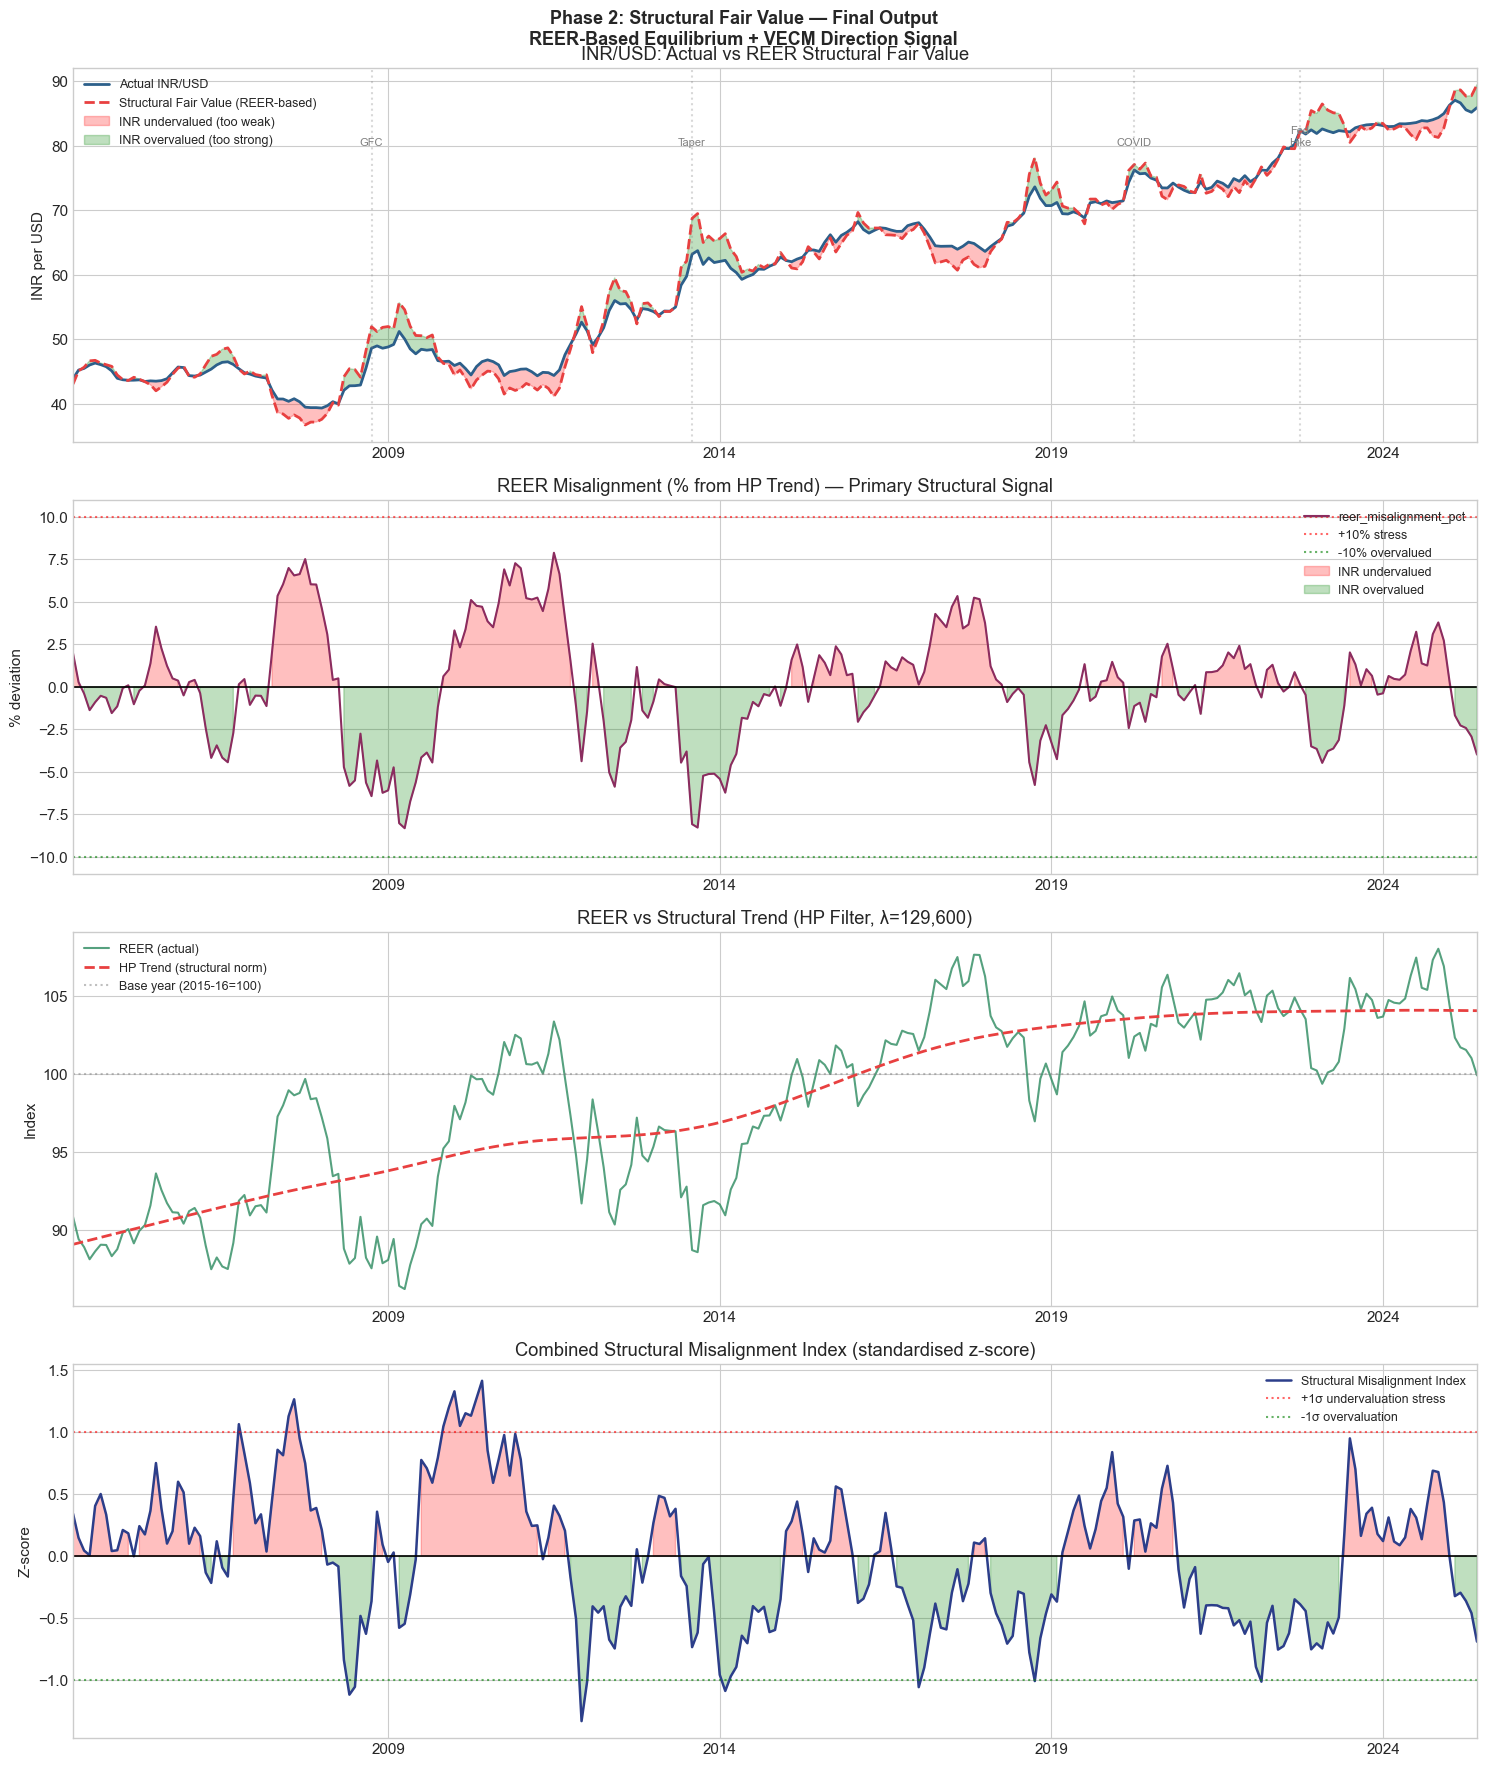

✓ Chart saved → ../outputs/02_structural_final.png


In [9]:
# ============================================================
# Phase 2 | Cell 6b: Save Structural Chart
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

PROCESSED = '../data/processed/'
plt.style.use('seaborn-v0_8-whitegrid')

# ── Reload all inputs ─────────────────────────────────────────
df       = model.copy()
phase2   = pd.read_csv(f'{PROCESSED}phase2_equilibrium.csv',
                       index_col=0, parse_dates=True)
phase2.index = pd.to_datetime(phase2.index).to_period('M').to_timestamp()

reer          = phase2['reer']
reer_trend    = phase2['reer_trend']
reer_dev      = phase2['reer_deviation']
inr_fair_reer = phase2['inr_fair_reer']
reer_misalign = phase2['reer_misalignment_pct']
ect2_s        = phase2['ect']
combined      = phase2['structural_misalignment_idx']

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 18))
fig.suptitle('Phase 2: Structural Fair Value — Final Output\n'
             'REER-Based Equilibrium + VECM Direction Signal',
             fontsize=13, fontweight='bold')

# Panel 1: INR/USD actual vs REER fair value
ax = axes[0]
res = pd.DataFrame({
    'actual': phase2['inr_usd'],
    'fair'  : inr_fair_reer
}).dropna()
res['actual'].plot(ax=ax, color='#2c5f8a', lw=2, label='Actual INR/USD')
res['fair'].plot(ax=ax, color='#e84040', lw=2, ls='--',
                 label='Structural Fair Value (REER-based)')
ax.fill_between(res.index, res['actual'], res['fair'],
                where=res['actual'] > res['fair'],
                alpha=0.25, color='red', label='INR undervalued (too weak)')
ax.fill_between(res.index, res['actual'], res['fair'],
                where=res['actual'] < res['fair'],
                alpha=0.25, color='green', label='INR overvalued (too strong)')
for d in ['2008-10-01', '2013-08-01', '2020-04-01', '2022-10-01']:
    ax.axvline(pd.Timestamp(d), color='gray', alpha=0.3, ls=':')
for d, label in [('2008-10-01','GFC'), ('2013-08-01','Taper'),
                 ('2020-04-01','COVID'), ('2022-10-01','Fed\nHike')]:
    y_pos = res['actual'].max() * 0.92
    ax.text(pd.Timestamp(d), y_pos, label, fontsize=8,
            color='gray', ha='center')
ax.set_title('INR/USD: Actual vs REER Structural Fair Value')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9, loc='upper left')

# Panel 2: REER misalignment %
ax = axes[1]
reer_misalign.dropna().plot(ax=ax, color='#8b2c5f', lw=1.5)
ax.axhline(0,   color='black', lw=1.2)
ax.axhline(10,  color='red',   ls=':', alpha=0.6, label='+10% stress')
ax.axhline(-10, color='green', ls=':', alpha=0.6, label='-10% overvalued')
ax.fill_between(reer_misalign.dropna().index, reer_misalign.dropna(), 0,
                where=reer_misalign.dropna() > 0, alpha=0.25, color='red',
                label='INR undervalued')
ax.fill_between(reer_misalign.dropna().index, reer_misalign.dropna(), 0,
                where=reer_misalign.dropna() < 0, alpha=0.25, color='green',
                label='INR overvalued')
ax.set_title('REER Misalignment (% from HP Trend) — Primary Structural Signal')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

# Panel 3: REER vs HP trend
ax = axes[2]
reer.plot(ax=ax, color='#2c8a5f', lw=1.5, alpha=0.8, label='REER (actual)')
reer_trend.plot(ax=ax, color='#e84040', lw=2, ls='--',
                label='HP Trend (structural norm)')
ax.axhline(100, color='gray', ls=':', alpha=0.5, label='Base year (2015-16=100)')
ax.set_title('REER vs Structural Trend (HP Filter, λ=129,600)')
ax.set_ylabel('Index')
ax.legend(fontsize=9)

# Panel 4: Combined structural index
ax = axes[3]
combined.plot(ax=ax, color='#2c3e8a', lw=1.8, label='Structural Misalignment Index')
ax.axhline(0,  color='black', lw=1.2)
ax.axhline(1,  color='red',   ls=':', alpha=0.6, label='+1σ undervaluation stress')
ax.axhline(-1, color='green', ls=':', alpha=0.6, label='-1σ overvaluation')
ax.fill_between(combined.index, combined, 0,
                where=combined > 0, alpha=0.25, color='red')
ax.fill_between(combined.index, combined, 0,
                where=combined < 0, alpha=0.25, color='green')
ax.set_title('Combined Structural Misalignment Index (standardised z-score)')
ax.set_ylabel('Z-score')
ax.legend(fontsize=9)

plt.tight_layout()
path = '../outputs/02_structural_final.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Chart saved → {path}")

PHASE 2 FINAL — SIGN-CORRECTED OUTPUT

  Historical validation:
  Episode           REER   Trend   Misalign  Assessment
  ──────────────────────────────────────────────────────────
  2004-04           90.9    89.1      -1.9%   [Sample start]
  2007-01           91.5    92.0      +0.5%   [Pre-GFC boom]
  2008-10           87.6    93.6      +6.9%   [GFC peak]
  2011-11           94.8    95.9      +1.2%   [EM pressure]
  2013-08           88.7    96.5      +8.8%   [Taper tantrum]
  2016-11          102.6   101.1      -1.5%   [Demonetisation]
  2018-10           97.0   102.9      +6.1%   [EM selloff]
  2020-04          102.4   103.6      +1.1%   [COVID]
  2022-10          104.2   104.0      -0.1%   [Fed tightening]
  2025-06           99.9   104.1      +4.1%   [Latest]

  Summary statistics (corrected):
    Range          : -7.3% to +9.1%
    Mean           : +0.11%
    Std            : 3.28%
    Stress months (>+5%)  : 20  out of 255
    Overvalued months (<-5%): 16 out of 255

  Current 

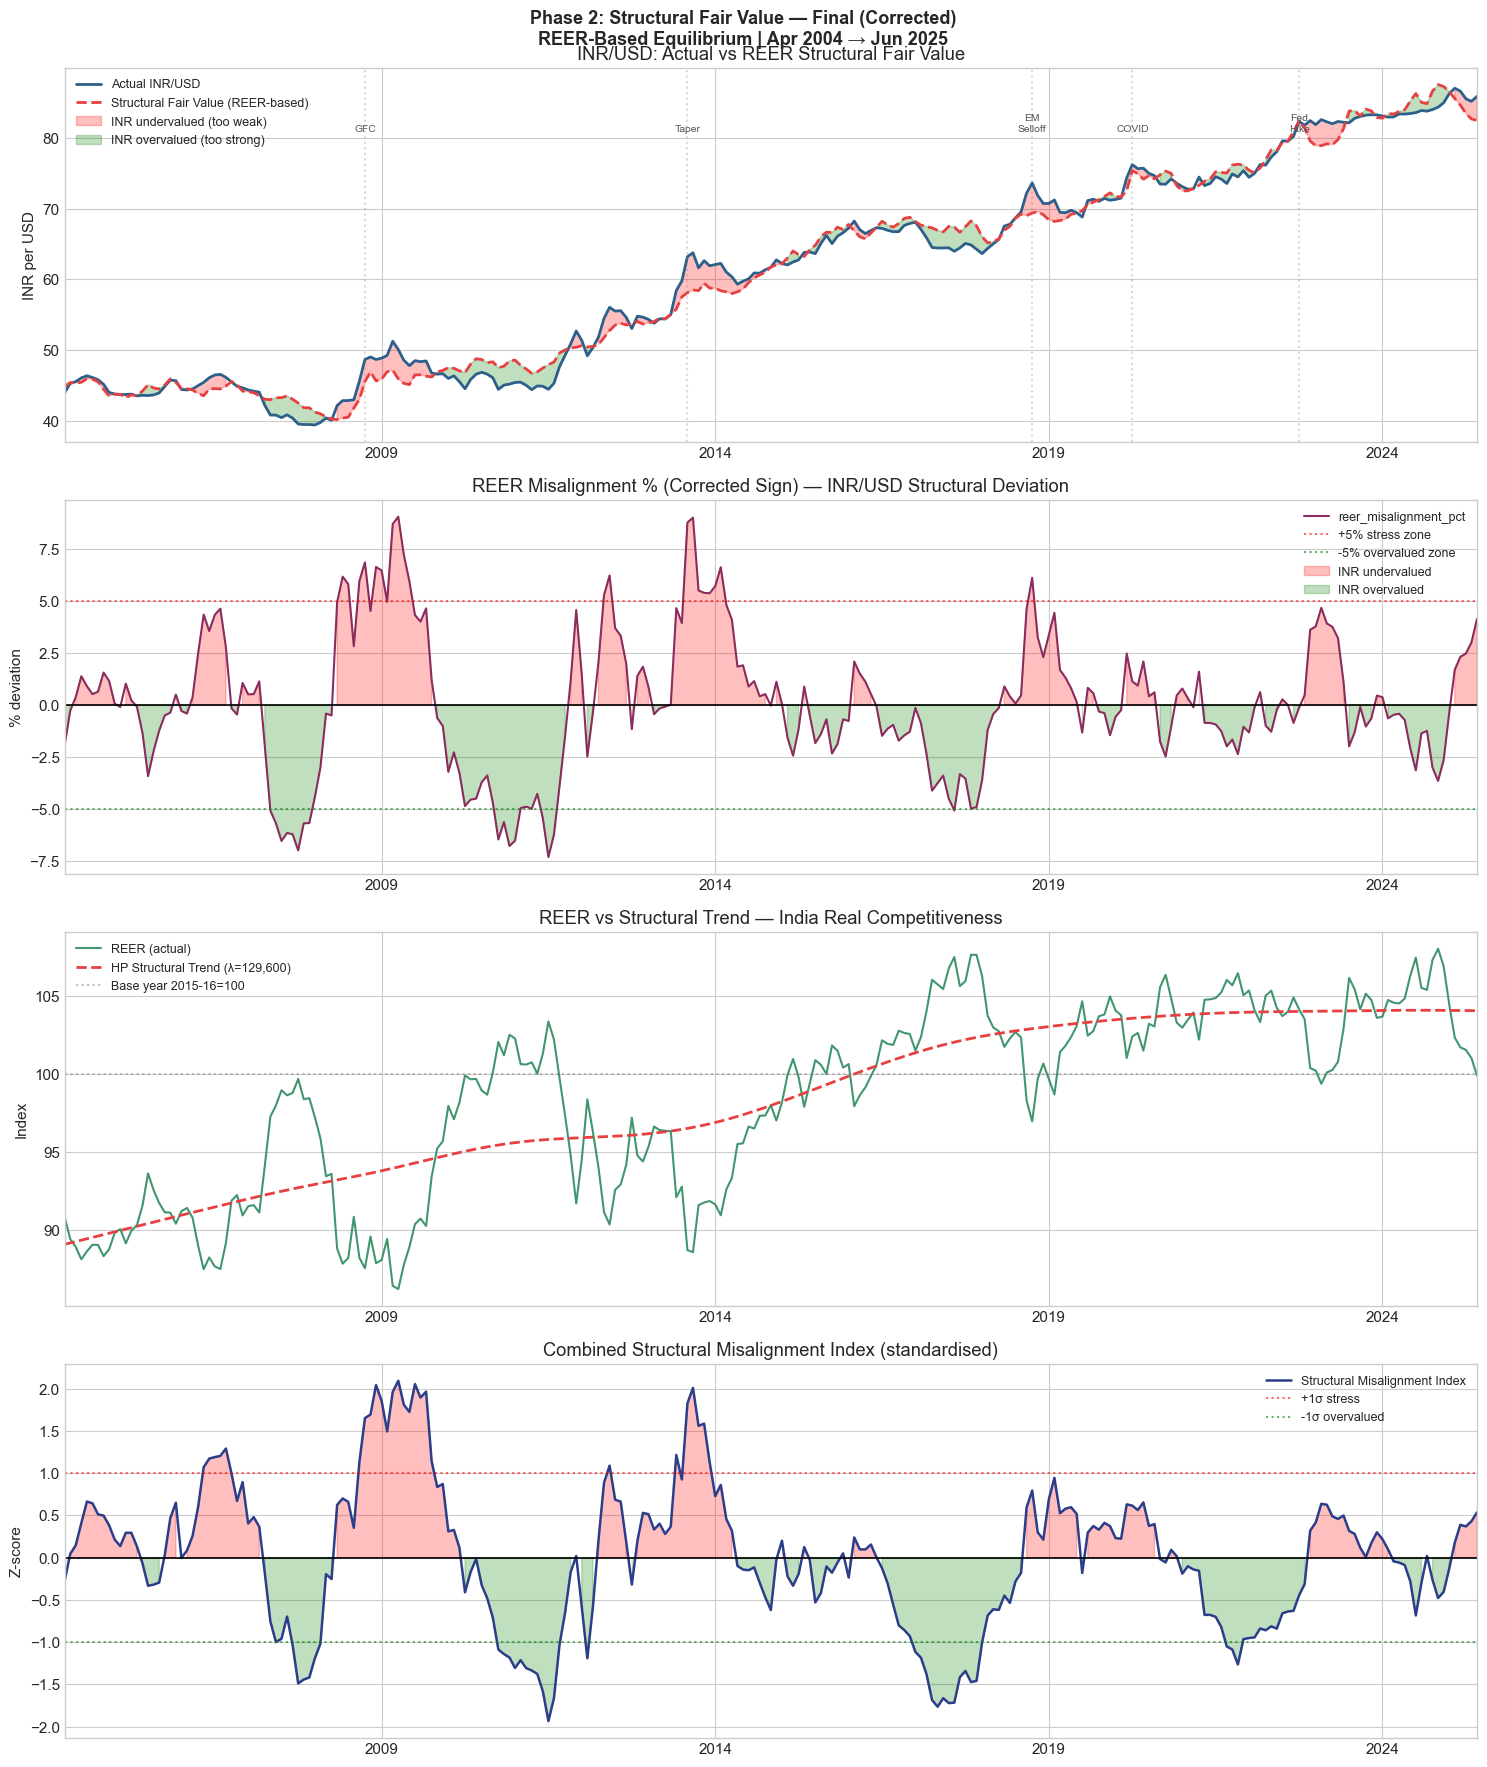


✓ phase2_equilibrium.csv overwritten with corrected values
  255 months × 8 columns

✓ Chart saved → outputs/02_structural_final_corrected.png


In [10]:
# ============================================================
# Phase 2 | Cell 7: Sign Fix + Final Clean Output
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

PROCESSED = '../data/processed/'
plt.style.use('seaborn-v0_8-whitegrid')

df = model.copy()

reer     = df['reer'].dropna()
_, reer_trend = hpfilter(reer, lamb=129600)
reer_trend = reer_trend.reindex(df.index)

# ── CORRECTED formula ─────────────────────────────────────────
# REER < trend → INR depreciated beyond structural norm
# → fair INR/USD < actual → misalignment positive = undervalued
inr_fair_reer  = df['inr_usd'] * (reer / reer_trend)
inr_fair_reer.name = 'inr_fair_reer'

reer_misalign  = ((df['inr_usd'] - inr_fair_reer) / inr_fair_reer) * 100
reer_misalign.name = 'reer_misalignment_pct'

reer_dev = reer - reer_trend
reer_dev.name = 'reer_deviation'

# Load ECT from saved file
saved  = pd.read_csv(f'{PROCESSED}phase2_equilibrium.csv',
                     index_col=0, parse_dates=True)
ect_s  = saved['ect']
ect_s.index = pd.to_datetime(ect_s.index).to_period('M').to_timestamp()

# Combined index (standardised)
reer_z = (reer_misalign - reer_misalign.mean()) / reer_misalign.std()
ect_z  = (ect_s - ect_s.mean()) / ect_s.std()
combined = ((reer_z + ect_z) / 2).dropna()
combined.name = 'structural_misalignment_idx'

print("=" * 60)
print("PHASE 2 FINAL — SIGN-CORRECTED OUTPUT")
print("=" * 60)

print("\n  Historical validation:")
print(f"  {'Episode':<15} {'REER':>6} {'Trend':>7} "
      f"{'Misalign':>10}  Assessment")
print("  " + "─" * 58)
for date, desc in [('2004-04-01','Sample start'),
                   ('2007-01-01','Pre-GFC boom'),
                   ('2008-10-01','GFC peak'),
                   ('2011-11-01','EM pressure'),
                   ('2013-08-01','Taper tantrum'),
                   ('2016-11-01','Demonetisation'),
                   ('2018-10-01','EM selloff'),
                   ('2020-04-01','COVID'),
                   ('2022-10-01','Fed tightening'),
                   ('2025-06-01','Latest'),]:
    try:
        dt  = pd.Timestamp(date)
        r   = reer.loc[dt]
        t   = reer_trend.loc[dt]
        m   = reer_misalign.loc[dt]
        inr = df.loc[dt, 'inr_usd']
        print(f"  {date[:7]:<15} {r:>6.1f} {t:>7.1f} "
              f"  {m:>+7.1f}%   [{desc}]")
    except:
        pass

print(f"\n  Summary statistics (corrected):")
mc = reer_misalign.dropna()
print(f"    Range          : {mc.min():+.1f}% to {mc.max():+.1f}%")
print(f"    Mean           : {mc.mean():+.2f}%")
print(f"    Std            : {mc.std():.2f}%")
print(f"    Stress months (>+5%)  : {(mc>5).sum()}  out of {len(mc)}")
print(f"    Overvalued months (<-5%): {(mc<-5).sum()} out of {len(mc)}")
print()
print(f"  Current readings (Jun 2025):")
print(f"    Actual INR/USD        : {df['inr_usd'].dropna().iloc[-1]:.2f}")
print(f"    Structural fair value : {inr_fair_reer.dropna().iloc[-1]:.2f}")
print(f"    REER misalignment     : {reer_misalign.dropna().iloc[-1]:+.1f}%")
print(f"    Combined index        : {combined.iloc[-1]:+.2f}σ")
print()
print(f"  ⚠  HP filter end-point note:")
print(f"     Last 12-18 months have smaller misalignment readings")
print(f"     because HP trend has no future data to smooth against.")
print(f"     Treat post-2024 misalignment as indicative, not precise.")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 18))
fig.suptitle('Phase 2: Structural Fair Value — Final (Corrected)\n'
             'REER-Based Equilibrium | Apr 2004 → Jun 2025',
             fontsize=13, fontweight='bold')

# Panel 1
ax = axes[0]
res = pd.DataFrame({'actual': df['inr_usd'], 'fair': inr_fair_reer}).dropna()
res['actual'].plot(ax=ax, color='#2c5f8a', lw=2, label='Actual INR/USD')
res['fair'].plot(ax=ax, color='#e84040', lw=2, ls='--',
                 label='Structural Fair Value (REER-based)')
ax.fill_between(res.index, res['actual'], res['fair'],
                where=res['actual'] > res['fair'],
                alpha=0.25, color='red', label='INR undervalued (too weak)')
ax.fill_between(res.index, res['actual'], res['fair'],
                where=res['actual'] < res['fair'],
                alpha=0.25, color='green', label='INR overvalued (too strong)')
for d, label in [('2008-10-01','GFC'),('2013-08-01','Taper'),
                 ('2018-10-01','EM\nSelloff'),('2020-04-01','COVID'),
                 ('2022-10-01','Fed\nHike')]:
    ax.axvline(pd.Timestamp(d), color='gray', alpha=0.3, ls=':')
    ax.text(pd.Timestamp(d), res['actual'].max()*0.93, label,
            fontsize=7.5, color='#555', ha='center')
ax.set_title('INR/USD: Actual vs REER Structural Fair Value')
ax.set_ylabel('INR per USD')
ax.legend(fontsize=9, loc='upper left')

# Panel 2 — REER misalignment (corrected)
ax = axes[1]
m_plot = reer_misalign.dropna()
m_plot.plot(ax=ax, color='#8b2c5f', lw=1.5)
ax.axhline(0, color='black', lw=1.2)
ax.axhline(5, color='red', ls=':', alpha=0.6, label='+5% stress zone')
ax.axhline(-5, color='green', ls=':', alpha=0.6, label='-5% overvalued zone')
ax.fill_between(m_plot.index, m_plot, 0,
                where=m_plot>0, alpha=0.25, color='red', label='INR undervalued')
ax.fill_between(m_plot.index, m_plot, 0,
                where=m_plot<0, alpha=0.25, color='green', label='INR overvalued')
ax.set_title('REER Misalignment % (Corrected Sign) — INR/USD Structural Deviation')
ax.set_ylabel('% deviation')
ax.legend(fontsize=9)

# Panel 3 — REER vs HP trend
ax = axes[2]
reer.plot(ax=ax, color='#2c8a5f', lw=1.5, alpha=0.9, label='REER (actual)')
reer_trend.dropna().plot(ax=ax, color='#e84040', lw=2, ls='--',
                         label='HP Structural Trend (λ=129,600)')
ax.axhline(100, color='gray', ls=':', alpha=0.5, label='Base year 2015-16=100')
ax.set_title('REER vs Structural Trend — India Real Competitiveness')
ax.set_ylabel('Index')
ax.legend(fontsize=9)

# Panel 4 — Combined index
ax = axes[3]
combined.plot(ax=ax, color='#2c3e8a', lw=1.8, label='Structural Misalignment Index')
ax.axhline(0, color='black', lw=1.2)
ax.axhline(1, color='red', ls=':', alpha=0.6, label='+1σ stress')
ax.axhline(-1, color='green', ls=':', alpha=0.6, label='-1σ overvalued')
ax.fill_between(combined.index, combined, 0,
                where=combined>0, alpha=0.25, color='red')
ax.fill_between(combined.index, combined, 0,
                where=combined<0, alpha=0.25, color='green')
ax.set_title('Combined Structural Misalignment Index (standardised)')
ax.set_ylabel('Z-score')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_structural_final_corrected.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Overwrite phase2_equilibrium.csv ─────────────────────────
phase2_out = pd.DataFrame({
    'inr_usd'                    : df['inr_usd'],
    'reer'                       : df['reer'],
    'reer_trend'                 : reer_trend,
    'reer_deviation'             : reer_dev,
    'inr_fair_reer'              : inr_fair_reer,
    'reer_misalignment_pct'      : reer_misalign,
    'ect'                        : ect_s,
    'structural_misalignment_idx': combined,
}, index=df.index).dropna()

phase2_out.to_csv(f'{PROCESSED}phase2_equilibrium.csv')
print(f"\n✓ phase2_equilibrium.csv overwritten with corrected values")
print(f"  {len(phase2_out)} months × {phase2_out.shape[1]} columns")
print(f"\n✓ Chart saved → outputs/02_structural_final_corrected.png")